In [1]:
# Importing required libraries
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
%matplotlib inline
import seaborn as sns
import scipy.stats as si
import statsmodels.api as sm
from statsmodels.tsa.ar_model import AutoReg
from scipy import stats as st
from scipy.optimize import least_squares
from tabulate import tabulate
import warnings
warnings.filterwarnings("ignore")
from scipy.stats.mstats import gmean
import statsmodels.formula.api as smf
import itertools
from itertools import product

c:\Users\YeonChan Kang\anaconda3\envs\fdb\lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [28]:
import statsmodels.tsa.api as tsa

In [2]:
from scipy.stats import zscore

In [3]:
import wrds
conn = wrds.Connection()

WRDS recommends setting up a .pgpass file.
Created .pgpass file successfully.
You can create this file yourself at any time with the create_pgpass_file() function.
Loading library list...
Done


# Data

In [4]:
# Factor Theme
usa_th_ew = pd.read_csv("C:/Users/YeonChan Kang/Desktop/Local_repo/Factor-Momentum-Reversal-and-Turning-Point/data/themes/[usa]_[all_themes]_[monthly]_[ew].csv")
usa_th_vw = pd.read_csv("C:/Users/YeonChan Kang/Desktop/Local_repo/Factor-Momentum-Reversal-and-Turning-Point/data/themes/[usa]_[all_themes]_[monthly]_[vw].csv")
usa_th_cvw = pd.read_csv("C:/Users/YeonChan Kang/Desktop/Local_repo/Factor-Momentum-Reversal-and-Turning-Point/data/themes/[usa]_[all_themes]_[monthly]_[vw_cap].csv")

# Factor
usa_fac_ew = pd.read_csv("C:/Users/YeonChan Kang/Desktop/Local_repo/Factor-Momentum-Reversal-and-Turning-Point/data/factors/[usa]_[all_factors]_[monthly]_[ew].csv")
usa_fac_vw = pd.read_csv("C:/Users/YeonChan Kang/Desktop/Local_repo/Factor-Momentum-Reversal-and-Turning-Point/data/factors/[usa]_[all_factors]_[monthly]_[vw].csv")
usa_fac_cvw = pd.read_csv("C:/Users/YeonChan Kang/Desktop/Local_repo/Factor-Momentum-Reversal-and-Turning-Point/data/factors/[usa]_[all_factors]_[monthly]_[vw_cap].csv")

In [6]:
# Manipulating the format of the data
usa_fac_ew.drop(columns = ['freq', 'weighting', 'location','n_stocks', 'n_stocks_min', 'direction'], inplace = True)
usa_fac_ew = usa_fac_ew.pivot_table(index='date', columns='name', values='ret')

usa_fac_vw.drop(columns = ['freq', 'weighting', 'location','n_stocks', 'n_stocks_min', 'direction'], inplace = True)
usa_fac_vw = usa_fac_vw.pivot_table(index='date', columns='name', values='ret')

usa_fac_cvw.drop(columns = ['freq', 'weighting', 'location','n_stocks', 'n_stocks_min', 'direction'], inplace = True)
usa_fac_cvw = usa_fac_cvw.pivot_table(index='date', columns='name', values='ret')

In [7]:
usa_fac_ew.index = pd.to_datetime(usa_fac_ew.index)
usa_fac_ew.index = usa_fac_ew.index.to_period('M')

usa_fac_cvw.index = pd.to_datetime(usa_fac_cvw.index)
usa_fac_cvw.index = usa_fac_cvw.index.to_period('M')

usa_fac_vw.index = pd.to_datetime(usa_fac_vw.index)
usa_fac_vw.index = usa_fac_vw.index.to_period('M')

In [8]:
ff_data = conn.raw_sql("""
                       SELECT *
                       FROM ff.factors_monthly
                       WHERE date between '01/01/1926' and '12/31/2023'
                       """)

In [9]:
ff_data.drop(columns=['date'], inplace=True)
ff_data.index.name = 'date'
ff_data.set_index('dateff', inplace=True)
ff_data.index = pd.to_datetime(ff_data.index)
ff_data.index = ff_data.index.to_period('M')

In [37]:
usa_fac_ewm = pd.merge(ff_data[['mktrf']], usa_fac_ew, left_index=True, right_index=True, how='outer')

usa_fac_vwm = pd.merge(ff_data[['mktrf']], usa_fac_vw, left_index=True, right_index=True, how='outer')

usa_fac_cvwm = pd.merge(ff_data[['mktrf']], usa_fac_cvw, left_index=True, right_index=True, how='outer')

# Momentum Turning Points

In [13]:
# Creating the lagged and rolling variables
usa_fac_ew_r1 = usa_fac_ew.copy()

for col in usa_fac_ew.columns:
    usa_fac_ew_r1[f'{col}_1m'] = usa_fac_ew[col].shift(1).astype(float)

usa_fac_ew_r12 = usa_fac_ew.copy()

for col in usa_fac_ew.columns:
    usa_fac_ew_r12[f'{col}_12m'] = usa_fac_ew[col].shift(1).rolling(12).mean().astype(float)

In [14]:
# Creating the state of the factor

usa_fac_ew_State = pd.DataFrame(index=usa_fac_ew.index)

for col in usa_fac_ew.columns:
    usa_fac_ew_State[f'{col}_State_t'] = np.where(np.isnan(usa_fac_ew_r1[f'{col}_1m']) | np.isnan(usa_fac_ew_r12[f'{col}_12m']), None,
    np.where(
        (usa_fac_ew_r1[f'{col}_1m'] >= 0) & (usa_fac_ew_r12[f'{col}_12m'] >= 0), 'Bull',
        np.where(
            (usa_fac_ew_r1[f'{col}_1m'] < 0) & (usa_fac_ew_r12[f'{col}_12m'] < 0), 'Bear',
            np.where(
                (usa_fac_ew_r1[f'{col}_1m'] < 0) & (usa_fac_ew_r12[f'{col}_12m'] >= 0), 'Correction',
                'Rebound'
            )
        )
    )
)

In [15]:
# Creating the lagged and rolling variables for the state of the factor

usa_fac_ew_State_tp1 = pd.DataFrame(index=usa_fac_ew.index)

for col in usa_fac_ew_State.columns:
    usa_fac_ew_State_tp1[f'{col}p1'] = usa_fac_ew_State[f'{col}'].shift(-1)

usa_fac_ew_State_tm1 = pd.DataFrame(index=usa_fac_ew.index)

for col in usa_fac_ew_State.columns:
    usa_fac_ew_State_tm1[f'{col}m1'] = usa_fac_ew_State[f'{col}'].shift(1)

## Factor Cycles

In [ ]:
# Set the color and order of the states

colors = {'Bull': "lightgreen", 'Correction': "cornflowerblue", 'Bear': "lightcoral",'Rebound':'gray'}
order = ['Bull','Correction','Bear','Rebound'] # Maintain this order in graphs

In [ ]:
def plot_relative_frequency(df, column, order=None, colors=None, save_path=None, img_show=None):
    """
    Plot the relative frequency of the states in a specified column of a DataFrame.
    
    Parameters:
    df (pd.DataFrame): The input DataFrame.
    column (str): The column name for which to calculate and plot the relative frequency.
    order (list): The order of the categories to be displayed on the x-axis. Default is None.
    colors (list): The colors for the bars in the plot. Default is None.
    """
    # Drop missing values in the column
    df = df.dropna(subset=[column])
    
    # Calculate relative frequency
    freq = round(df[column].value_counts(normalize=True), 3) * 100
    freq = freq.reset_index()
    freq.rename(columns={'index': column, column: 'Freq'}, inplace=True)
    
    # Set plot style
    sns.set_style("whitegrid")
    
    # Create the bar plot
    ax = sns.barplot(x='Freq', y='proportion', data=freq, order=order, palette=colors)
    
    # Add bar labels
    ax.bar_label(ax.containers[0], fontsize='large')
    
    # Set plot labels and title
    plt.xlabel("Previous Month's State", fontsize='x-large')
    plt.ylabel(f'{col} Relative Frequency (%)', fontsize='x-large')
    plt.title(f'{col} Relative Frequency (%)', fontsize='x-large')
    
    # Save the plot if save_path is provided
    if save_path:
        plt.savefig(save_path, bbox_inches='tight')
    
    # Show the plot
    if img_show:
        plt.show()
        
    # Clear the figure to avoid overlaying plots
    plt.clf()
    plt.close()

In [ ]:
# Relative Frequency of States

for col in usa_fac_ew_State.columns:
    relative_frequency_path = f"C:/Users/YeonChan Kang/Desktop/Local_repo/Factor-Momentum-Reversal-and-Turning-Point/image/relative_frequency_path/{col}.png"
    plot_relative_frequency(usa_fac_ew_State, col, order=order, colors=colors, save_path=relative_frequency_path)

### Figure 1 (a): Avg. Subsequent Return

In [ ]:
def plot_subsequent_return(df, state_column, return_column, order=None, colors=None, save_path=None, img_show=None):
    """
    Plot the average subsequent return (annualized) for each state in a specified column of a DataFrame.
    
    Parameters:
    df (pd.DataFrame): The input DataFrame.
    state_column (str): The column name for the state.
    return_column (str): The column name for the return.
    order (list): The order of the categories to be displayed on the x-axis. Default is None.
    colors (list): The colors for the bars in the plot. Default is None.
    """
    
    # Drop missing values in the columns
    df = df.dropna(subset=[state_column, return_column])
    # Calculate mean subsequent returns (annualized)
    mean = round((df.groupby(state_column)[return_column].mean()) * 12, 3) * 100
    mean = mean.reset_index()
    
    # Set plot style
    sns.set_style("whitegrid")
    
    # Create the bar plot
    ax = sns.barplot(x=state_column, y=return_column, data=mean, order=order, palette=colors)
    
    # Add bar labels
    ax.bar_label(ax.containers[0], fontsize='large')
    
    # Set plot labels and title
    plt.xlabel("Previous Month's State", fontsize='x-large')
    plt.ylabel('Avg. Subsequent Return (anlzd., %)', fontsize='x-large')
    plt.title(f'{return_column} Avg. Subsequent Return (anlzd., %)', fontsize='x-large')
    
    # Save the plot if save_path is provided
    if save_path:
        plt.savefig(save_path, bbox_inches='tight')
    
    # Show the plot
    if img_show:
        plt.show()
        
    # Clear the figure to avoid overlaying plots
    plt.clf()
    plt.close()

In [ ]:
usa_fac_ew_r_State = pd.concat([usa_fac_ew ,usa_fac_ew_State],axis=1)

# Subsequent Return (anlzd., %)

for c1, c2 in zip(usa_fac_ew_State.columns, usa_fac_ew.columns):
    relative_frequency_path = f"C:/Users/YeonChan Kang/Desktop/Local_repo/Factor-Momentum-Reversal-and-Turning-Point/image/subsequent_return/{c2}.png"
    plot_subsequent_return(usa_fac_ew_r_State, c1, c2, order=order, colors=colors, save_path=relative_frequency_path)

### Subsequent Vol

In [ ]:
def plot_subsequent_return_volatility(df, state_column, return_column, order=None, colors=None, save_path=None, img_show=None):
    """
    Plot the subsequent return volatility (annualized) for each state in a specified column of a DataFrame.
    
    Parameters:
    df (pd.DataFrame): The input DataFrame.
    state_column (str): The column name for the state.
    return_column (str): The column name for the return.
    order (list): The order of the categories to be displayed on the x-axis. Default is None.
    colors (list): The colors for the bars in the plot. Default is None.
    """
    
    # Drop missing values in the specified columns
    df = df.dropna(subset=[state_column, return_column])
    
    # Calculate standard deviation of subsequent returns (annualized)
    stdd = round(df.groupby(state_column)[return_column].std() * (12 ** 0.5) * 100, 1)
    stdd = stdd.reset_index()  # Create a new DataFrame
    
    # Rename the stdd column for clarity in the plot
    stdd.rename(columns={return_column: 'Subsequent_Return_Vol'}, inplace=True)
    
    # Set plot style
    sns.set_style("whitegrid")
    
    # Create the bar plot
    ax = sns.barplot(x=state_column, y='Subsequent_Return_Vol', data=stdd, order=order, palette=colors)
    
    # Add bar labels
    ax.bar_label(ax.containers[0], fontsize='large')
    
    # Set plot labels and title
    plt.xlabel("Previous Month's State", fontsize='x-large')
    plt.ylabel('Subsequent Return Vol. (anlzd., %)', fontsize='x-large')
    plt.title(f'{return_column}Subsequent Return Vol. (anlzd., %)', fontsize='x-large')
    
    # Save the plot if save_path is provided
    if save_path:
        plt.savefig(save_path, bbox_inches='tight')
    
    # Show the plot
    if img_show:
        plt.show()
        
    # Clear the figure to avoid overlaying plots
    plt.clf()
    plt.close()

In [ ]:
# Subsequent Return VOl (anlzd., %)

for c1, c2 in zip(usa_fac_ew_State.columns, usa_fac_ew.columns):
    relative_frequency_path = f"C:/Users/YeonChan Kang/Desktop/Local_repo/Factor-Momentum-Reversal-and-Turning-Point/image/subsequent_return_vol/{c2}.png"
    plot_subsequent_return_volatility(usa_fac_ew_r_State, c1, c2, order=order, colors=colors, save_path=relative_frequency_path)

### Subsequent Skewness

In [ ]:
def plot_subsequent_return_skewness(df, state_column, return_column, order=None, colors=None, save_path=None, img_show=None):
    """
    Plot the subsequent return skewness for each state in a specified column of a DataFrame.
    
    Parameters:
    df (pd.DataFrame): The input DataFrame.
    state_column (str): The column name for the state.
    return_column (str): The column name for the return.
    order (list): The order of the categories to be displayed on the x-axis. Default is None.
    colors (list): The colors for the bars in the plot. Default is None.
    save_path (str): The path to save the plot image. If None, the plot will not be saved. Default is None.
    """
    
    # Ensure all missing values are np.nan
    df[state_column] = df[state_column].replace({None: np.nan, '': np.nan})
    df[return_column] = df[return_column].replace({None: np.nan, '': np.nan})
    
    # Drop missing values in the specified columns
    df = df.dropna(subset=[state_column, return_column])
    
    # Calculate skewness of subsequent returns
    skeww = round(df.groupby(state_column)[return_column].skew(), 2)
    skeww = skeww.reset_index()  # Create a new DataFrame
    
    # Rename the skewness column for clarity in the plot
    skeww.rename(columns={return_column: 'Subsequent_Return_Skewness'}, inplace=True)
    
    # Set plot style
    sns.set_style("whitegrid")
    
    # Create the bar plot
    ax = sns.barplot(x=state_column, y='Subsequent_Return_Skewness', data=skeww, order=order, palette=colors)
    
    # Add bar labels
    ax.bar_label(ax.containers[0], fontsize='large')
    
    # Set plot labels and title
    plt.xlabel("Previous Month's State", fontsize='x-large')
    plt.ylabel('Subsequent Return Skewness', fontsize='x-large')
    plt.title('Subsequent Return Skewness', fontsize='x-large')
    
    # Save the plot if save_path is provided
    if save_path:
        plt.savefig(save_path, bbox_inches='tight')
    
    # Show the plot
    if img_show:
        plt.show()
    
    # Clear the figure to avoid overlaying plots
    plt.clf()
    plt.close()

In [ ]:
# Subsequent skewness

for c1, c2 in zip(usa_fac_ew_State.columns, usa_fac_ew.columns):
    relative_frequency_path = f"C:/Users/YeonChan Kang/Desktop/Local_repo/Factor-Momentum-Reversal-and-Turning-Point/image/subsequent_return_skewness/{c2}.png"
    plot_subsequent_return_skewness(usa_fac_ew_r_State, c1, c2, order=order, colors=colors, save_path=relative_frequency_path)

# Factor Momentum, Recversal

In [16]:
# Persistence Calculation 
def calculate_persistence(df, past_months=12, future_months=1):
    momentum_results = {}
    for factor in df.columns:
        past_returns = df[factor].rolling(window=past_months).mean().shift(future_months)
        future_returns = df[factor].shift(-future_months)
        correlation = past_returns.corr(future_returns)
        momentum_results[factor] = correlation
    return momentum_results

# Reversal 분석 함수
def calculate_reversal(df, past_months=12, future_months=1):
    reversal_results = {}
    for factor in df.columns:
        past_returns = df[factor].rolling(window=past_months).mean().shift(future_months)
        future_returns = df[factor].shift(-future_months)
        negative_correlation = past_returns.corr(future_returns) * -1
        reversal_results[factor] = negative_correlation
    return reversal_results

momentum_results = calculate_momentum(usa_fac_ewm)
reversal_results = calculate_reversal(usa_fac_ewm)

In [452]:
def momentum_regression(df, past_months=12, future_months=1):
    results = {}
    for factor in df.columns:
        past_returns = df[factor].rolling(window=past_months).mean().shift(future_months)
        future_returns = df[factor].shift(-future_months)
        
        # Drop NaN values
        data = pd.concat([past_returns, future_returns], axis=1).dropna()
        past_returns = data.iloc[:, 0]
        future_returns = data.iloc[:, 1]
        
        # Add constant term for intercept
        X = sm.add_constant(past_returns)
        y = future_returns
        
        # Fit the regression model
        model = sm.OLS(y, X).fit()
        results[factor] = model
    return results

momentum_reg_results = momentum_regression(usa_fac_ewm)

In [454]:
def reversal_regression(df, past_months=12, future_months=1):
    results = {}
    for factor in df.columns:
        past_returns = df[factor].rolling(window=past_months).mean().shift(future_months)
        future_returns = df[factor].shift(-future_months)
        
        # Drop NaN values
        data = pd.concat([past_returns, future_returns], axis=1).dropna()
        past_returns = data.iloc[:, 0]
        future_returns = data.iloc[:, 1]
        
        # Add constant term for intercept
        X = sm.add_constant(past_returns)
        y = future_returns
        
        # Fit the regression model
        model = sm.OLS(y, X).fit()
        results[factor] = model
    return results

reversal_reg_results = reversal_regression(usa_fac_ewm)

In [450]:
def print_regression_results(results):
    for factor, model in results.items():
        print(f"Factor: {factor}")
        print(model.summary())
        print("\n")

# Factor Momentum Everywhere

## AR(1)

In [18]:
def plot_and_save_factor_returns(df, save_plots=False, output_dir='factor_returns', img_show=None):
    """
    Plot and save the factor returns for each factor in a DataFrame.
    
    Parameters:
    df (pd.DataFrame): The input DataFrame containing factor returns.
    save_plots (bool): Whether to save the plots as images. Default is False.
    output_dir (str): The directory to save the plots. Default is 'factor_returns'.
    img_show (bool): Whether to display the plots. Default is None.
    """
    # Create output directory if it does not exist
    if save_plots and not os.path.exists(output_dir):
        os.makedirs(output_dir)
    
    # Plot and save each factor
    for column in df.columns:
        plt.figure(figsize=(10, 5))
        plt.plot(df.index, df[column], label=column)
        plt.title(f'Returns for {column}')
        plt.xlabel('Date')
        plt.ylabel('Return')
        plt.legend()
        plt.grid(True)
        
        plt.xticks(rotation=45)
        
        if save_plots:
            plt.savefig(os.path.join(output_dir, f'{column}_returns.png'))
        
        if img_show:
            plt.show()

In [ ]:
plot_and_save_factor_returns(usa_fac_ew_r1.drop(columns= usa_fac_ew.columns), True, "C:/Users/YeonChan Kang/Desktop/Local_repo/Factor-Momentum-Reversal-and-Turning-Point/image/return_ar(1)")

plot_and_save_factor_returns(usa_fac_ew_r12.drop(columns= usa_fac_ew.columns), True, "C:/Users/YeonChan Kang/Desktop/Local_repo/Factor-Momentum-Reversal-and-Turning-Point/image/return_ar(12)")

## Cumulative Return

In [6]:
def calculate_cumulative_sum(df):
    # Calculate cumulative sum for each factor
    cumulative_sum = df.cumsum()
    return cumulative_sum

def plot_and_save_cumulative_returns(df, save_plots=False, output_dir='cumulative_returns', img_shows=True):
    cumulative_returns = calculate_cumulative_sum(df)
    
    # Create output directory if it does not exist
    if save_plots and not os.path.exists(output_dir):
        os.makedirs(output_dir)
    
    # Plot and save cumulative returns for each factor
    for column in df.columns:
        plt.figure(figsize=(10, 5))
        plt.plot(df.index, cumulative_returns[column], label=f'Cumulative {column}')
        plt.title(f'Cumulative Returns for {column}')
        plt.xlabel('Date')
        plt.ylabel('Cumulative Return')
        plt.legend()
        
        # Adding horizontal lines only on y-axis
        plt.grid(True, axis='y', linestyle='--', linewidth=0.5)
        
        # Setting x-axis ticks to be every 10 years
        plt.gca().xaxis.set_major_locator(plt.MaxNLocator(nbins=int(len(df.index) / (12*10))))
        
        # Set x-tick labels to be smaller
        plt.xticks(fontsize=8, rotation=45)
        
        if save_plots:
            plt.savefig(os.path.join(output_dir, f'cumulative_{column}_returns.png'))
        
        if img_shows:
            plt.show()
        else:
            plt.close()

In [ ]:
plot_and_save_cumulative_returns(usa_fac_ew, True, "C:/Users/YeonChan Kang/Desktop/Local_repo/Factor-Momentum-Reversal-and-Turning-Point/image/cumulative_returns", False)

## Alpha

In [211]:
def calculate_statistics(df, factor_name, rf_col='rf', annualization_method='compound'):
    
    df = df.dropna(subset=[factor_name])
    
    if rf_col is not None:
        y = df[factor_name] - df[rf_col]
    else:
        y = df[factor_name]
    
    X = df['mktrf']
    X = sm.add_constant(X)
    
    # Calculate average returns (Annualized)
    avg_return_ann = df[factor_name].mean() * 12
    avg_return_std = df[factor_name].std() * np.sqrt(12)
    avg_return_ci = st.t.interval(0.95, len(df[factor_name])-1, loc=avg_return_ann, scale=st.sem(df[factor_name]*12))
    
    # Calculate volatility (Annualized)
    volatility_ann = df[factor_name].std() * np.sqrt(12)
    volatility_ci = (volatility_ann - avg_return_std, volatility_ann + avg_return_std)

    # Calculate Sharpe Ratio
    sharpe_ratio = avg_return_ann / volatility_ann
    sharpe_ratio_ci = st.t.interval(0.95, len(df[factor_name])-1, loc=sharpe_ratio, scale=st.sem(df[factor_name] / volatility_ann))

    """
    # Calculate Information Ratio
    tracking_error = (X - Y).std() * np.sqrt(12) 
    
    if tracking_error != 0:
        info_ratio = (df['mktrf'].mean() * 12) / tracking_error
    else:
        info_ratio = np.nan
    """
    
    model = sm.OLS(y, X).fit()
    monthly_alpha = model.params['const']
    beta = model.params['mktrf']
    alpha_ci = model.conf_int().loc['const'].values * 12
    beta_ci = model.conf_int().loc['mktrf'].values

    # Annualize alpha
    if annualization_method == 'compound':
        annual_alpha = ((1 + monthly_alpha) ** 12) - 1
    elif annualization_method == 'simple':
        annual_alpha = monthly_alpha * 12
    else:
        ValueError("annualization_method must be 'compound' or 'simple'")

    # Compile results
    results = {
        'Average Returns (Ann. %)': round(avg_return_ann * 100, 2),
        'Volatility (Ann. %)': round(volatility_ann * 100, 2),
        'Sharpe Ratio': round(sharpe_ratio, 2),
         # 'Info. Ratio': info_ratio,
        'Alpha (Ann. %)': round(annual_alpha * 100, 2),
        'Beta': round(beta, 2)
    }
    
    ci_results = {
        'Average Returns (Ann. %)': (round(avg_return_ci[0] * 100, 2), round(avg_return_ci[1] * 100, 2)),
        'Volatility (Ann. %)': (round(volatility_ci[0] * 100, 2), round(volatility_ci[1] * 100, 2)),
        'Sharpe Ratio': (round(sharpe_ratio_ci[0], 2), round(sharpe_ratio_ci[1], 2)),
        'Alpha (Ann. %)': (round(alpha_ci[0] * 100, 2), round(alpha_ci[1] * 100, 2)),
        'Beta': (round(beta_ci[0], 2), round(beta_ci[1], 2))
    }
    
    formatted_results = {key: f"{value:.2f}" for key, value in results.items()}
    formatted_ci_results = {key: (f"{value[0]:.2f}", f"{value[1]:.2f}") for key, value in ci_results.items()}

    return formatted_results, formatted_ci_results

In [212]:
def calculate_statistics_for_periods(data, factor_name, risk_free_rate_col=None, annualization_method='compound'):
    if isinstance(data.index, pd.PeriodIndex):
        data.index = data.index.to_timestamp()  # Convert PeriodIndex to DatetimeIndex if necessary

    end_date = data.index.max()
    periods = {
        '1 Year': end_date - pd.DateOffset(years=1),
        '3 Years': end_date - pd.DateOffset(years=3),
        '5 Years': end_date - pd.DateOffset(years=5),
        '10 Years': end_date - pd.DateOffset(years=10),
        'Full Sample': data.index.min()
    }

    results = {}
    ci_results = {}
    for period_name, start_date in periods.items():
        filtered_data = data.loc[start_date:end_date]
        period_results, period_ci = calculate_statistics(filtered_data, factor_name, risk_free_rate_col, annualization_method=annualization_method)
        results[period_name] = period_results
        ci_results[period_name] = period_ci
    
    # Convert results to a DataFrame
    results_df = pd.DataFrame(results)  
    ci_results_df = pd.DataFrame(ci_results)  

    return results_df, ci_results_df


In [213]:
def calculate_all_factors(data, factors, risk_free_rate_col=None, annualization_method='compound'):
    all_results = {}
    all_ci_results = {}
    for factor in factors:
        results_df, ci_results_df = calculate_statistics_for_periods(data, factor, risk_free_rate_col, annualization_method=annualization_method)
        all_results[factor] = results_df
        all_ci_results[factor] = ci_results_df
    return all_results, all_ci_results

In [224]:
factor_ss, factor_ci_ss = calculate_all_factors(usa_fac_ewm, usa_fac_ewm.columns, risk_free_rate_col=None, annualization_method='simple')

In [227]:
def plot_statistics(all_results, all_ci_results, period, metric, output_path, show_plot=False):
    metric_map = {
        'average_return': 'Average Returns (Ann. %)',
        'volatility': 'Volatility (Ann. %)',
        'sharpe_ratio': 'Sharpe Ratio',
        'alpha': 'Alpha (Ann. %)',
        'beta': 'Beta'
    }
    
    if period not in ['1 Year', '3 Years', '5 Years', '10 Years', 'Full Sample']:
        raise ValueError("Invalid period. Choose from '1 Year', '3 Years', '5 Years', '10 Years', 'Full Sample'.")
    if metric not in metric_map:
        raise ValueError("Invalid metric. Choose from 'average_return', 'volatility', 'sharpe_ratio', 'alpha', 'beta'.")

    metric_label = metric_map[metric]

    factors = list(all_results.keys())
    values = [float(all_results[factor][period][metric_label]) for factor in factors]
    ci_lower = [float(all_results[factor][period][metric_label]) - float(all_ci_results[factor][period][metric_label][0]) for factor in factors]
    ci_upper = [float(all_ci_results[factor][period][metric_label][1]) - float(all_results[factor][period][metric_label]) for factor in factors]

    # Create a DataFrame to facilitate sorting
    df = pd.DataFrame({
        'factor': factors,
        'value': values,
        'ci_lower': ci_lower,
        'ci_upper': ci_upper
    })

    # Sort the DataFrame by 'value' in ascending order
    df = df.sort_values(by='value')

    # Extract sorted values
    sorted_factors = df['factor'].tolist()
    sorted_values = df['value'].tolist()
    sorted_ci_lower = df['ci_lower'].tolist()
    sorted_ci_upper = df['ci_upper'].tolist()

    plt.figure(figsize=(16, 10))  # Increased figure size
    plt.bar(sorted_factors, sorted_values, yerr=[sorted_ci_lower, sorted_ci_upper], capsize=5, color='gray', alpha=0.7)
    plt.xticks(rotation=90, fontsize=10)  # Increased font size for factor names
    plt.xlabel('Factors', fontsize=12)
    plt.ylabel(metric_label, fontsize=12)
    plt.title(f'{metric_label} for {period}', fontsize=14)
    plt.grid(True)
    plt.tight_layout()
    
    # Save the plot to the specified path
    if output_path is not None:
        plt.savefig(output_path)
    
    # Show the plot if requested
    if show_plot:
        plt.show()
    else:
        plt.close()

In [228]:
factor_annaul_ret = "C:/Users/YeonChan Kang/Desktop/Local_repo/Factor-Momentum-Reversal-and-Turning-Point/image/factor_ss/factor_annual_ret.png"
plot_statistics(factor_ss, factor_ci_ss, 'Full Sample', 'average_return', factor_annaul_ret)

factor_annaul_alpha = "C:/Users/YeonChan Kang/Desktop/Local_repo/Factor-Momentum-Reversal-and-Turning-Point/image/factor_ss/factor_annual_alpha.png"
plot_statistics(factor_ss, factor_ci_ss, 'Full Sample', 'alpha', factor_annaul_alpha)

factor_annaul_sharpratio = "C:/Users/YeonChan Kang/Desktop/Local_repo/Factor-Momentum-Reversal-and-Turning-Point/image/factor_ss/factor_annual_sharpratio.png"
plot_statistics(factor_ss, factor_ci_ss, 'Full Sample', 'sharpe_ratio', factor_annaul_sharpratio)

In [219]:
factor_ss['ret_1_0']

,1 Year,3 Years,5 Years,10 Years,Full Sample
Average Returns (Ann. %),7.01,-1.26,4.22,3.00,13.48
Volatility (Ann. %),22.02,14.58,15.18,11.88,12.76
Sharpe Ratio,0.32,-0.09,0.28,0.25,1.06
Alpha (Ann. %),-1.38,-3.35,-0.29,-0.70,11.95
Beta,0.66,0.25,0.37,0.33,0.19


In [229]:
usa_fac_ew

name,age,aliq_at,aliq_mat,ami_126d,at_be,at_gr1,at_me,at_turnover,be_gr1a,be_me,...,taccruals_at,taccruals_ni,tangibility,tax_gr1a,turnover_126d,turnover_var_126d,z_score,zero_trades_126d,zero_trades_21d,zero_trades_252d
date,,,,,,,,,,,,,,,,,,,,,
1926-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1926-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.033729,NaN
1926-03,-0.066167,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.025194,NaN
1926-04,0.010546,NaN,NaN,0.000735,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,-0.011262,0.014204,NaN,-0.013378,-0.019000,NaN
1926-05,-0.020292,NaN,NaN,-0.013176,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,-0.002660,-0.001504,NaN,0.001122,-0.009408,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-08,-0.054567,0.002399,-0.001066,-0.047448,-0.003451,-0.020061,-0.007403,0.043529,-0.025323,-0.021121,...,-0.031117,0.003720,-0.008152,0.023259,0.074987,0.035290,0.050579,0.073846,0.075131,0.067512
2023-09,-0.033245,-0.012930,-0.018309,-0.022491,-0.011440,-0.017367,0.005463,0.026197,-0.023414,0.001572,...,-0.034718,-0.000075,0.001992,0.000153,0.047818,0.022536,0.025393,0.047604,0.048954,0.044560
2023-10,-0.064723,0.011269,-0.003807,-0.045575,-0.031388,-0.013805,-0.008455,0.020299,-0.016057,-0.004598,...,-0.022756,0.014109,0.007450,0.008461,0.058655,0.039382,0.041032,0.057859,0.045431,0.064437


# Factor Persistence

In [230]:
periods = {
    '1-1': (1, 1),
    '1-3': (1, 3),
    '1-6': (1, 6),
    '1-12': (1, 12),
    '1-36': (1, 36),
    '1-60': (1, 60),
    '2-12': (2, 12),
    '13-60': (13, 60)
}

# Factor Persistence 계산 함수
def calculate_persistence(data, periods):
    persistence_results = {}
    for period_name, (start, end) in periods.items():
        persistence_results[period_name] = {}
        for factor in data.columns:
            factor_returns = data[factor]
            persistence = factor_returns.shift(start).rolling(end).mean()
            persistence_results[period_name][factor] = persistence.mean()
    return pd.DataFrame(persistence_results)

# Persistence 계산
persistence_results = calculate_persistence(usa_fac_ewm, periods)

In [233]:
def factor_momentum_strategy(data, periods):
    strategy_results = {}
    for period_name, (start, end) in periods.items():
        strategy_results[period_name] = {}
        for factor in data.columns:
            factor_returns = data[factor]
            # 이전 수익률 계산
            previous_returns = factor_returns.shift(start).rolling(end).mean()
            # 매수/매도 신호 생성 (이전 수익률이 양수이면 매수, 음수이면 매도)
            signals = np.where(previous_returns > 0, 1, -1)
            # 전략 수익률 계산
            strategy_returns = signals * factor_returns
            strategy_results[period_name][factor] = strategy_returns.cumsum().iloc[-1]
    return pd.DataFrame(strategy_results)

# 전략 수익률 계산
strategy_results = factor_momentum_strategy(usa_fac_ewm, periods)
strategy_results

,1-1,1-3,1-6,1-12,1-36,1-60,2-12,13-60
mktrf,4.611400,2.578600,3.717600,6.953000,2.846400,3.962600,3.974800,5.609200
smb,3.278600,2.336200,0.859800,3.170200,1.994800,0.826200,2.326200,-0.519800
hml,4.807800,4.462600,3.418400,3.895400,1.487000,2.817200,1.660200,0.953200
umd,2.104900,3.193300,4.271900,3.474700,4.318900,3.627700,3.426900,5.230900
age,5.320693,4.209372,3.144028,4.171748,1.270606,1.031326,3.155249,-2.036700
...,...,...,...,...,...,...,...,...
turnover_var_126d,0.889535,1.418047,1.097903,4.294342,2.166483,0.063690,3.103427,0.195388
z_score,2.297250,2.397572,2.347716,1.969801,0.427702,0.519044,1.645406,-0.914437
zero_trades_126d,-1.924106,-0.253212,0.911381,4.442509,3.677744,4.915121,3.716263,4.390507
zero_trades_21d,-0.754922,-2.281042,-1.169909,2.376733,2.385499,0.806614,1.584544,-0.115609


In [234]:
def calculate_persistence_d(data, periods):
    persistence_results = {}
    for factor in data.columns:
        persistence_results[factor] = pd.DataFrame(index=data.index)
        for period_name, (start, end) in periods.items():
            factor_returns = data[factor]
            persistence = factor_returns.shift(start).rolling(end).mean()
            persistence_results[factor][period_name] = persistence
    return persistence_results

# Persistence 계산
persistence_results = calculate_persistence_d(usa_fac_ewm, periods)

In [273]:
persistence_results

{'mktrf':                1-1       1-3       1-6      1-12      1-36      1-60  \
 1926-07-01     NaN       NaN       NaN       NaN       NaN       NaN   
 1926-08-01  0.0296       NaN       NaN       NaN       NaN       NaN   
 1926-09-01  0.0264       NaN       NaN       NaN       NaN       NaN   
 1926-10-01  0.0036  0.019867       NaN       NaN       NaN       NaN   
 1926-11-01 -0.0324 -0.000800       NaN       NaN       NaN       NaN   
 ...            ...       ...       ...       ...       ...       ...   
 2023-08-01  0.0321  0.033400  0.017600  0.008425  0.010214  0.009357   
 2023-09-01 -0.0239  0.024267  0.017917  0.009575  0.007431  0.008385   
 2023-10-01 -0.0524 -0.014733  0.005000  0.013000  0.006983  0.007502   
 2023-11-01 -0.0319 -0.036067 -0.001333  0.003817  0.006681  0.008250   
 2023-12-01  0.0884  0.001367  0.012817  0.007350  0.005672  0.009442   
 
                 2-12     13-60  
 1926-07-01       NaN       NaN  
 1926-08-01       NaN       NaN  
 1926-09-01

In [237]:
def factor_momentum_strategy_d(data, periods):
    strategy_results = {}
    for factor in data.columns:
        strategy_results[factor] = pd.DataFrame(index=data.index)
        for period_name, (start, end) in periods.items():
            factor_returns = data[factor]
            # 이전 수익률 계산
            previous_returns = factor_returns.shift(start).rolling(end).mean()
            # 매수/매도 신호 생성 (이전 수익률이 양수이면 매수, 음수이면 매도)
            signals = np.where(previous_returns.isna(), np.nan, np.where(previous_returns > 0, 1, -1))
            # 전략 수익률 계산
            strategy_returns = signals * factor_returns
            strategy_results[factor][period_name] = strategy_returns.cumsum()
    return strategy_results

# 전략 수익률 계산
strategy_results = factor_momentum_strategy_d(usa_fac_ewm, periods)

In [274]:
usa_fac_ewm['market_equity'].shift(2).rolling(12).mean()

1926-07-01         NaN
1926-08-01         NaN
1926-09-01         NaN
1926-10-01         NaN
1926-11-01         NaN
                ...   
2023-08-01   -0.014846
2023-09-01   -0.011527
2023-10-01   -0.018750
2023-11-01   -0.019577
2023-12-01   -0.018866
Freq: MS, Name: market_equity, Length: 1170, dtype: float64

In [281]:
usa_fac_ewm['market_equity'].shift(1).rolling(1).mean()

1926-07-01         NaN
1926-08-01   -0.025937
1926-09-01    0.014871
1926-10-01   -0.010626
1926-11-01   -0.008012
                ...   
2023-08-01    0.002674
2023-09-01   -0.051764
2023-10-01   -0.026257
2023-11-01   -0.045762
2023-12-01   -0.019387
Freq: MS, Name: market_equity, Length: 1170, dtype: float64

In [283]:
np.where(usa_fac_ewm['market_equity'].shift(1).rolling(1).mean().dropna() > 0, 1, -1)

array([-1,  1, -1, ..., -1, -1, -1])

In [286]:
strategy_results['market_equity']['1-1']

1926-07-01         NaN
1926-08-01   -0.014871
1926-09-01   -0.010626
1926-10-01    0.008012
1926-11-01    0.019822
                ...   
2023-08-01   -0.051764
2023-09-01    0.026257
2023-10-01    0.045762
2023-11-01    0.019387
2023-12-01   -0.035934
Freq: MS, Name: market_equity, Length: 1170, dtype: float64

In [ ]:
def factor_momentum_strategy(data, periods):
    strategy_results = {}
    for factor in data.columns:
        strategy_results[factor] = {}
        for period_name, (start, end) in periods.items():
            factor_returns = data[factor]
            # 이전 수익률 계산
            previous_returns = factor_returns.shift(start).rolling(end).mean()
            # nan 값이 포함되어 있으면 nan으로 반환
            # 매수/매도 신호 생성 (이전 수익률이 양수이면 매수, 음수이면 매도)
            signals = np.where(previous_returns.isna(), np.nan, np.where(previous_returns > 0, 1, -1))
            # 전략 수익률 계산
            strategy_returns = signals * factor_returns
            strategy_results[factor][period_name] = pd.Series(strategy_returns, index=data.index)
    return strategy_results

# 전략 수익률 계산
strategy_results = factor_momentum_strategy(usa_fac_ewm, periods)
strategy_results

In [318]:
def calculate_average_return(data):
    return data.mean() * 12 * 100  # 연간화 및 백분율

# 전체 기간의 Cumulative Return 계산 함수
def calculate_cumulative_return(data, compound=True):
    if compound:
        return ((1 + data).prod() - 1)
    else:
        return data.sum()

# Sharpe Ratio 계산 함수
def calculate_sharpe_ratio(data, rf_rate=0.0):
    excess_returns = data - rf_rate
    annualized_excess_returns = excess_returns.mean() * 12  # 연간화
    annualized_volatility = excess_returns.std() * np.sqrt(12)  # 연간화
    return annualized_excess_returns / annualized_volatility

# CAPM Alpha 계산 함수
def calculate_capm_alpha(data, market_returns, rf_rate=0.0):
    excess_returns = data - rf_rate
    excess_market_returns = market_returns - rf_rate
    X = sm.add_constant(excess_market_returns)
    model = sm.OLS(excess_returns, X).fit()
    alpha = model.params['const']
    return alpha * 12 * 100  # 연간화 및 백분율

# Helper function to calculate various metrics
def calculate_metrics(data, market_returns, rf_rate=0.0, compound=True):
    avg_return = calculate_average_return(data)
    cum_return = calculate_cumulative_return(data, compound)
    sharpe_ratio = calculate_sharpe_ratio(data, rf_rate)
    capm_alpha = calculate_capm_alpha(data, market_returns, rf_rate)
    
    # 소수점 둘째 자리까지 반올림
    avg_return = round(avg_return, 2)
    cum_return = round(cum_return, 2)
    sharpe_ratio = round(sharpe_ratio, 2)
    capm_alpha = round(capm_alpha, 2)
    
    # 소수점 둘째 자리로 포맷팅
    avg_return = f"{avg_return:.2f}"
    cum_return = f"{cum_return:.2f}"
    sharpe_ratio = f"{sharpe_ratio:.2f}"
    capm_alpha = f"{capm_alpha:.2f}"
    
    return avg_return, cum_return, sharpe_ratio, capm_alpha

In [319]:
def factor_momentum_strategy(data, periods):
    strategy_results = {}
    for factor in data.columns:
        if factor == 'market':  # Skip market returns
            continue
        strategy_results[factor] = {}
        for period_name, (start, end) in periods.items():
            factor_returns = data[factor]
            # 이전 수익률 계산
            previous_returns = factor_returns.shift(start).rolling(end).mean()
            # NaN 값을 유지하면서 신호 생성
            signals = np.where(previous_returns.isna(), np.nan, np.where(previous_returns > 0, 1, -1))
            # 전략 수익률 계산
            strategy_returns = signals * factor_returns
            strategy_results[factor][period_name] = pd.Series(strategy_returns, index=data.index)
    return strategy_results


In [320]:
def calculate_period_metrics_df(strategy_results, market_returns, periods, rf_rate=0.0, compound=True):
    metrics_results = {}
    for factor in strategy_results.keys():
        period_results = []
        for period_name in periods.keys():
            strategy_returns = strategy_results[factor][period_name].dropna()
            aligned_market_returns = market_returns.loc[strategy_returns.index]
            avg_return, cum_return, sharpe_ratio, capm_alpha = calculate_metrics(strategy_returns, aligned_market_returns, rf_rate, compound)
            period_results.append({
                'Period': period_name,
                'Average Return': avg_return,
                'Cumulative Return': cum_return,
                'Sharpe Ratio': sharpe_ratio,
                'CAPM Alpha': capm_alpha
            })
        metrics_results[factor] = pd.DataFrame(period_results).set_index('Period')
    return metrics_results


In [321]:
def plot_factor_metrics(metrics_results_df, period, metric, output_path=None, show_plot=True):
    metric_map = {
        'avg_return': 'Average Return',
        'cum_return': 'Cumulative Return',
        'sharpe_ratio': 'Sharpe Ratio',
        'capm_alpha': 'CAPM Alpha'
    }
    
    if metric not in metric_map:
        raise ValueError("Invalid metric. Choose from 'avg_return', 'cum_return', 'sharpe_ratio', 'capm_alpha'.")
    
    metric_label = metric_map[metric]
    
    # 각 팩터의 데이터프레임에서 선택한 기간의 지표를 추출하여 데이터프레임으로 만듭니다.
    data = {factor: float(df.loc[period, metric_label]) for factor, df in metrics_results_df.items()}
    data_df = pd.DataFrame.from_dict(data, orient='index', columns=[metric_label]).reset_index()
    data_df.columns = ['Factor', metric_label]
    
    # 선택한 metric에 따라 오름차순으로 정렬
    data_df = data_df.sort_values(by=metric_label, ascending=True)
    
    # 시각화
    plt.figure(figsize=(12, 8))
    sns.barplot(x='Factor', y=metric_label, data=data_df, color='gray')
    plt.xticks(rotation=90)
    plt.title(f'{metric_label} for Period {period}')
    plt.xlabel('Factor')
    plt.ylabel(metric_label)
    plt.tight_layout()
    
    # 결과 저장 또는 표시
    if output_path:
        plt.savefig(output_path)
    
    if show_plot:
        plt.show()
    else:
        plt.close()

In [322]:
strategy_results = factor_momentum_strategy(usa_fac_ewm, periods)

In [323]:
metrics_results_df = calculate_period_metrics_df(strategy_results, usa_fac_ewm['mktrf'], periods)

In [334]:
def plot_factor_period_metrics(metrics_results_df, factor, metric, output_path=None, show_plot=True):
    metric_map = {
        'avg_return': 'Average Return',
        'cum_return': 'Cumulative Return',
        'sharpe_ratio': 'Sharpe Ratio',
        'capm_alpha': 'CAPM Alpha'
    }
    
    if metric not in metric_map:
        raise ValueError("Invalid metric. Choose from 'avg_return', 'cum_return', 'sharpe_ratio', 'capm_alpha'.")
    
    metric_label = metric_map[metric]
    
    # 선택한 팩터의 데이터프레임에서 지표를 추출
    data_df = metrics_results_df[factor].reset_index()
    data_df = data_df[['Period', metric_label]].copy()
    data_df[metric_label] = pd.to_numeric(data_df[metric_label], errors='coerce')
    
    # 시각화
    plt.figure(figsize=(10, 6))
    sns.barplot(x='Period', y=metric_label, data=data_df, color='gray', ci=None)
    
    """
    # 오차 막대 추가 (임의의 값으로 설정, 실제 데이터 사용 시 적절히 조정 필요)
    for i, row in data_df.iterrows():
        plt.errorbar(row['Period'], row[metric_label], yerr=1, fmt='none', c='black', capsize=5)
    """
    
    plt.title(f'{factor} - {metric_label}')
    plt.xlabel('Months in Formation Period')
    plt.ylabel(metric_label)
    plt.tight_layout()
    
    # 결과 저장 또는 표시
    if output_path:
        plt.savefig(output_path)
    
    if show_plot:
        plt.show()
    else:
        plt.close()

In [341]:
avg_ret_period_path = "C:/Users/YeonChan Kang/Desktop/Local_repo/Factor-Momentum-Reversal-and-Turning-Point/image/periods/avg_ret"
sharp_period_path = "C:/Users/YeonChan Kang/Desktop/Local_repo/Factor-Momentum-Reversal-and-Turning-Point/image/periods/sharp_ratio"
capm_alpha_period_path = "C:/Users/YeonChan Kang/Desktop/Local_repo/Factor-Momentum-Reversal-and-Turning-Point/image/periods/alpha"

for col in usa_fac_ewm.columns:
    plot_factor_period_metrics(metrics_results_df, col, 'avg_return', output_path=avg_ret_period_path + f'/{col}.png', show_plot=False)

for col in usa_fac_ewm.columns:
    plot_factor_period_metrics(metrics_results_df, col, 'sharpe_ratio', output_path=sharp_period_path + f'/{col}.png', show_plot=False)
    
for col in usa_fac_ewm.columns:
    plot_factor_period_metrics(metrics_results_df, col, 'capm_alpha', output_path=capm_alpha_period_path + f'/{col}.png', show_plot=False)


# TSFM EW Factor strategy

In [343]:
def generate_long_short_signals(data, periods):
    signals = {}
    for factor in data.columns:
        if factor == 'market':  # Skip market returns
            continue
        signals[factor] = {}
        for period_name, (start, end) in periods.items():
            factor_returns = data[factor]
            # 이전 수익률 계산
            previous_returns = factor_returns.shift(start).rolling(end).mean()
            # NaN 값을 유지하면서 신호 생성
            signals[factor][period_name] = np.where(previous_returns.isna(), np.nan, np.where(previous_returns > 0, 1, -1))
    return signals

In [344]:
def calculate_long_short_returns(data, signals, periods):
    long_short_returns = {}
    for factor in signals.keys():
        long_short_returns[factor] = {}
        for period_name in periods.keys():
            factor_returns = data[factor]
            signal = signals[factor][period_name]
            # long 및 short 포지션에 따른 수익률 계산
            long_returns = np.where(signal == 1, factor_returns, 0)
            short_returns = np.where(signal == -1, -factor_returns, 0)
            long_short_returns[factor][period_name] = long_returns + short_returns
    return long_short_returns

In [377]:
def calculate_overall_long_short_returns(data, long_short_returns, periods):
    overall_returns = {}
    for period_name in periods.keys():
        combined_returns = pd.Series(0, index=data.index)
        for factor in long_short_returns.keys():
            combined_returns += long_short_returns[factor][period_name]
        overall_returns[period_name] = combined_returns
    return overall_returns

In [378]:
signals = generate_long_short_signals(usa_fac_ewm, periods)
long_short_returns = calculate_long_short_returns(usa_fac_ewm, signals, periods)
overall_returns = calculate_overall_long_short_returns(usa_fac_ewm, long_short_returns, periods)


In [385]:
# 로그 수익률 계산 함수 (0 또는 음수 수익률 처리)
def log_returns(returns):
    adjusted_returns = returns + 1  # 1을 더해 음수 수익률 문제 해결
    log_returns = np.log(adjusted_returns)
    return log_returns

In [388]:
def plot_overall_returns(overall_returns, mktrf=None, output_path=None, show_plot=True, log_return=False): # log return 방법 추가
    # overall_returns를 데이터프레임으로 변환
    overall_returns_df = pd.DataFrame(overall_returns)
    
    if mktrf is not None:
        market_minus_rf = mktrf
        cumulative_market_minus_rf = market_minus_rf.cumsum()
    
    # 시각화
    plt.figure(figsize=(12, 8))
    for period in overall_returns_df.columns:
        if log_return:
            cumulative_returns = log_returns(overall_returns_df[period]).cumsum()
        else:
            cumulative_returns = overall_returns_df[period].cumsum()
        plt.plot(cumulative_returns, label=period)
    
    if mktrf is not None:
        plt.plot(cumulative_market_minus_rf, label='Market - Risk-Free Rate', linestyle='--', color='black')
    
    plt.title('Overall Long-Short Returns with Market - Risk-Free Rate')
    plt.xlabel('Date')
    plt.ylabel('Cumulative Returns')
    plt.legend(title='Period')
    plt.tight_layout()
    
    # 결과 저장 또는 표시
    if output_path:
        plt.savefig(output_path)
    
    if show_plot:
        plt.show()
    else:
        plt.close()

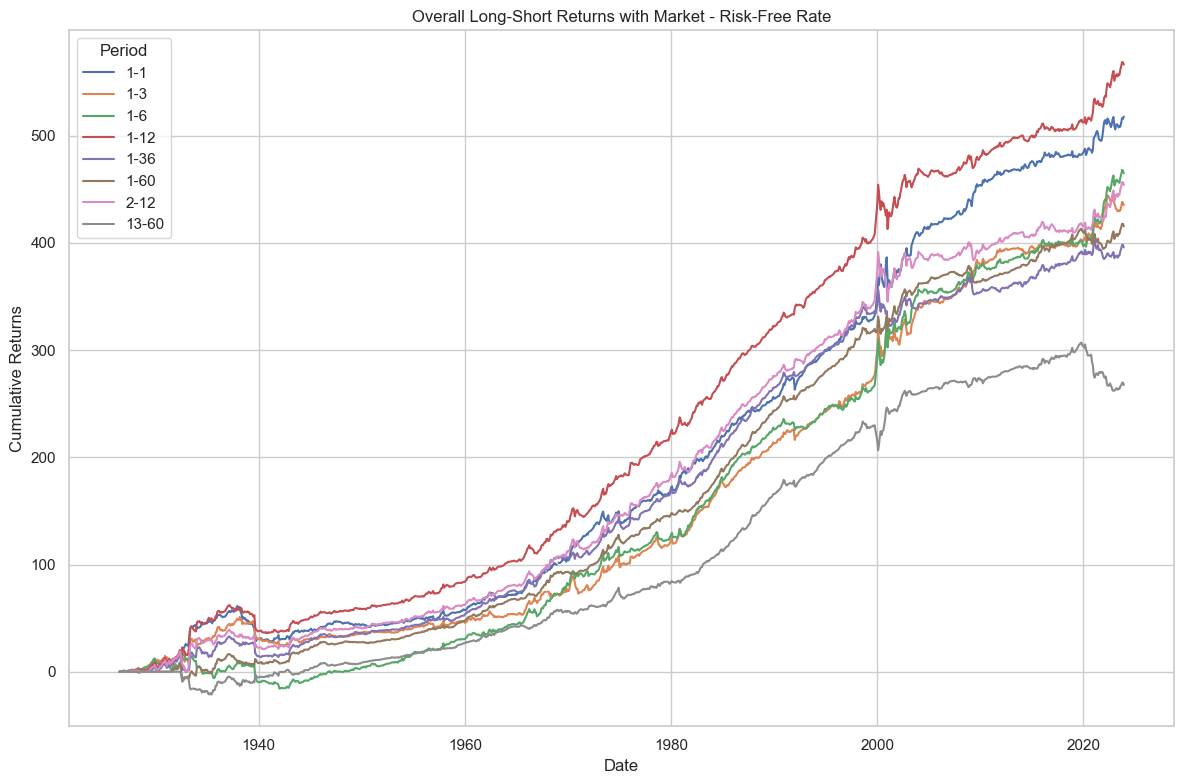

In [389]:
plot_overall_returns(overall_returns, None, output_path=None, show_plot=True, log_return=False)

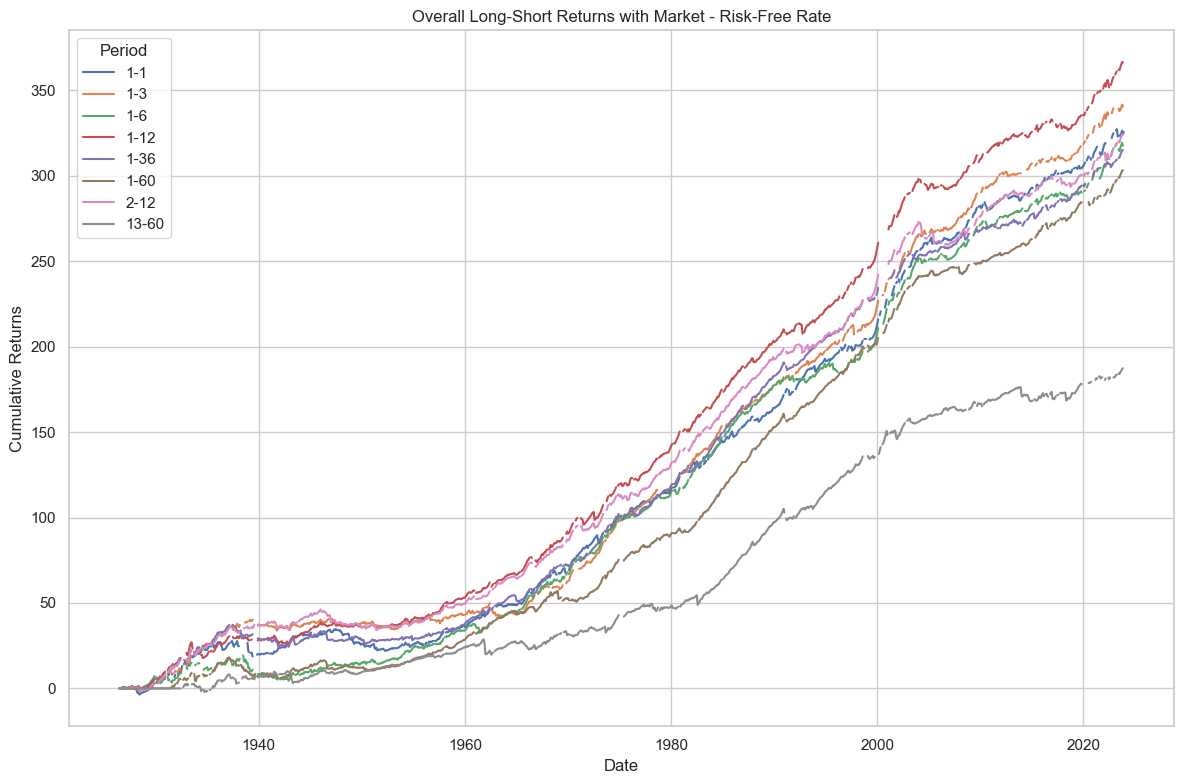

In [390]:
plot_overall_returns(overall_returns, None, output_path=None, show_plot=True, log_return=True)

In [429]:
def calculate_tsfm_strategy(data, periods, holding_period=1, annual_vol_window=36):
    """
    Calculate Time-Series Factor Momentum (TSFM) strategy.
    
    Parameters:
    - data: DataFrame containing factor returns.
    - periods: Dictionary of formation periods.
    - holding_period: Holding period for the strategy.
    - annual_vol_window: Window size for annualized volatility calculation.
    
    Returns:
    - tsfm_results: Dictionary containing TSFM returns for each period.
    - alphas: Dictionary containing alphas for each factor and period.
    """
    tsfm_results = {}
    alphas = {}
    
    for period_name, (start, end) in periods.items():
        tsfm_returns = pd.DataFrame(index=data.index)
        tsfm_scalings = pd.DataFrame(index=data.index)
        factor_alphas = {}

        for factor in data.columns:
            factor_returns = data[factor]
            
            # Calculate annualized volatility
            annual_volatility = factor_returns.rolling(window=annual_vol_window).std() * np.sqrt(12)
            
            # Calculate formation returns and scaling
            formation_returns = factor_returns.shift(start).rolling(window=end).mean()
            scaling = formation_returns / annual_volatility
            scaling = scaling.clip(-2, 2)  # Clipping between -2 and 2
            
            # Calculate TSFM returns
            tsfm_factor_returns = scaling.shift(1) * factor_returns.shift(-holding_period)
            tsfm_returns[factor] = tsfm_factor_returns
            tsfm_scalings[factor] = scaling.shift(1)

            # Regression to calculate alpha
            y = tsfm_factor_returns.dropna()
            X = sm.add_constant(factor_returns.loc[y.index])
            model = sm.OLS(y, X).fit()
            alpha = model.params['const']
            factor_alphas[factor] = alpha

        tsfm_results[period_name] = tsfm_returns
        alphas[period_name] = factor_alphas
    
    return tsfm_results, alphas

In [435]:
# Define formation periods
j_periods = [(1,1), (1,3), (1,6), (1,12), (1,36), (1,60), (2,12), (13,60)]

# Calculate TSFM strategy returns and alphas
tsfm_results, alphas = calculate_tsfm_strategy(usa_fac_ewm, periods)

In [428]:
tsfm_results

{(1,
  1):                mktrf       smb       hml       umd       age   aliq_at  \
 1926-07-01       NaN       NaN       NaN       NaN       NaN       NaN   
 1926-08-01       NaN       NaN       NaN       NaN       NaN       NaN   
 1926-09-01       NaN       NaN       NaN       NaN       NaN       NaN   
 1926-10-01       NaN       NaN       NaN       NaN       NaN       NaN   
 1926-11-01       NaN       NaN       NaN       NaN       NaN       NaN   
 ...              ...       ...       ...       ...       ...       ...   
 2023-08-01 -0.018368 -0.003613 -0.000229 -0.000389  0.008591  0.000413   
 2023-09-01 -0.005657 -0.007444  0.000435 -0.004268  0.006419 -0.000299   
 2023-10-01 -0.011572  0.000029 -0.001037  0.006543 -0.002065 -0.000351   
 2023-11-01 -0.013925 -0.014760  0.004456 -0.000898 -0.005379  0.005797   
 2023-12-01       NaN       NaN       NaN       NaN       NaN       NaN   
 
             aliq_mat  ami_126d     at_be    at_gr1  ...  taccruals_at  \
 1926-07-01   

In [437]:
def calculate_portfolio_returns(tsfm_results, periods):
    """
    Calculate TSFM portfolio returns.
    
    Parameters:
    - tsfm_results: Dictionary containing TSFM returns for each period.
    - periods: Dictionary of formation periods.
    
    Returns:
    - portfolio_returns: Dictionary containing portfolio returns for each period.
    """
    portfolio_returns = {}

    for period_name in periods.keys():
        tsfm_returns = tsfm_results[period_name]
        tsfm_scalings = tsfm_returns / tsfm_returns.abs()

        long_leg = tsfm_returns[tsfm_scalings > 0].sum(axis=1) / tsfm_scalings[tsfm_scalings > 0].sum(axis=1)
        short_leg = tsfm_returns[tsfm_scalings <= 0].sum(axis=1) / tsfm_scalings[tsfm_scalings <= 0].sum(axis=1)

        tsfm_portfolio = long_leg - short_leg
        portfolio_returns[period_name] = tsfm_portfolio.fillna(0)  # Fill NaN with 0 for missing values

    return portfolio_returns

In [ ]:
# Calculate portfolio returns
portfolio_returns = calculate_portfolio_returns(tsfm_results, j_periods, None)

In [439]:
def plot_portfolio_returns(portfolio_returns, log_return=False, output_path=None, show_plot=True):
    plt.figure(figsize=(12, 8))
    for j, returns in portfolio_returns.items():
        period_label = f"{j[0]}-{j[1]} months" if isinstance(j, tuple) else f"{j} months"
        cumulative_returns = (np.log1p(returns)).cumsum() if log_return else returns.cumsum()
        plt.plot(cumulative_returns, label=f'Formation Period: {period_label}')
    
    plt.title('TSFM Portfolio Cumulative Returns')
    plt.xlabel('Date')
    plt.ylabel('Cumulative Log Returns' if log_return else 'Cumulative Returns')
    plt.legend(title='Formation Period')
    plt.tight_layout()

    if output_path:
        plt.savefig(output_path)
    
    if show_plot:
        plt.show()
    else:
        plt.close()

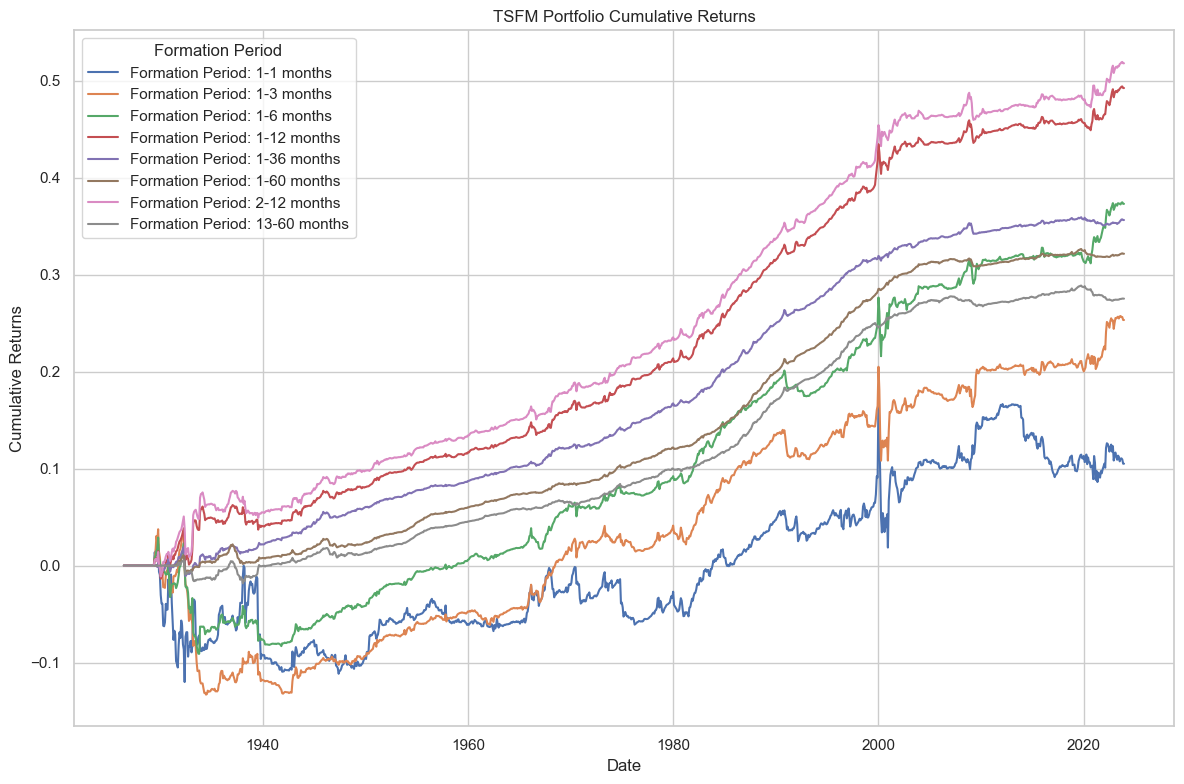

In [536]:
plot_portfolio_returns(portfolio_returns, log_return=False, output_path='tsfm_portfolio_returns.png', show_plot=True)

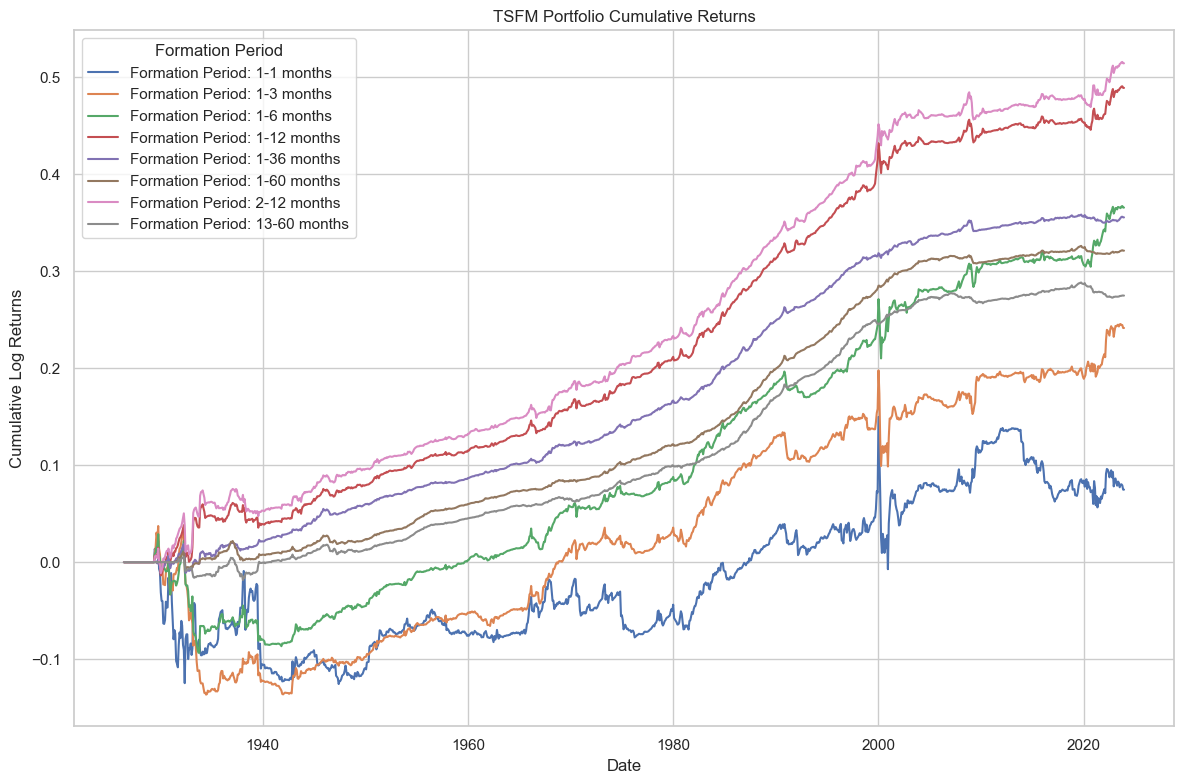

In [535]:
plot_portfolio_returns(portfolio_returns, log_return=True, output_path='tsfm_portfolio_returns.png', show_plot=True)

# Own Strategy factor momentum turning points

In [171]:
def calculate_momentum(data, period):
    """
    Calculate the momentum for a given period tuple (start, end).
    
    Parameters:
    - data: DataFrame containing factor returns.
    - period: Tuple (start, end) for momentum calculation.
    
    Returns:
    - momentum: DataFrame containing the momentum for each factor.
    """
    start, end = period
    return data.shift(start).rolling(window=end).mean()

def classify_states(data, fast_period, slow_period):
    """
    Classify the state of each factor based on fast and slow momentum.
    
    Parameters:
    - data: DataFrame containing factor returns.
    - fast_period: Tuple (start, end) for fast momentum calculation.
    - slow_period: Tuple (start, end) for slow momentum calculation.
    
    Returns:
    - states: Dictionary with factors as keys and their states as values.
    """
    states = {}
    
    # Calculate fast and slow momentum
    fast_momentum = calculate_momentum(data, fast_period)
    slow_momentum = calculate_momentum(data, slow_period)
    
    for factor in data.columns:
        factor_states = []

        for date in data.index:
            if pd.isna(fast_momentum.at[date, factor]) or pd.isna(slow_momentum.at[date, factor]):
                factor_states.append(np.nan)
                continue

            if fast_momentum.at[date, factor] > 0 and slow_momentum.at[date, factor] > 0:
                factor_states.append('Bull')
            elif fast_momentum.at[date, factor] > 0 and slow_momentum.at[date, factor] <= 0:
                factor_states.append('Rebound')
            elif fast_momentum.at[date, factor] <= 0 and slow_momentum.at[date, factor] > 0:
                factor_states.append('Correction')
            else:
                factor_states.append('Bear')
        
        states[factor] = pd.Series(factor_states, index=data.index)
    
    return states

In [458]:
states = classify_states(usa_fac_ewm, (1,1), (1,12))
states

{'mktrf': 1926-07-01                  NaN
 1926-08-01                  NaN
 1926-09-01                  NaN
 1926-10-01                  NaN
 1926-11-01                  NaN
                     ...        
 2023-08-01    positive_positive
 2023-09-01    negative_positive
 2023-10-01    negative_positive
 2023-11-01    negative_positive
 2023-12-01    positive_positive
 Freq: MS, Length: 1170, dtype: object,
 'smb': 1926-07-01                  NaN
 1926-08-01                  NaN
 1926-09-01                  NaN
 1926-10-01                  NaN
 1926-11-01                  NaN
                     ...        
 2023-08-01    positive_negative
 2023-09-01    negative_negative
 2023-10-01    negative_negative
 2023-11-01    negative_negative
 2023-12-01    negative_negative
 Freq: MS, Length: 1170, dtype: object,
 'hml': 1926-07-01                  NaN
 1926-08-01                  NaN
 1926-09-01                  NaN
 1926-10-01                  NaN
 1926-11-01                  NaN
      

In [530]:
pd.set_option('display.max_columns', 10)

In [160]:
def classify_states(data, fast_period, slow_period):
    """
    Classify the state of each factor based on fast and slow momentum.
    
    Parameters:
    - data: DataFrame containing factor returns.
    - fast_period: Tuple (start, end) for fast momentum calculation.
    - slow_period: Tuple (start, end) for slow momentum calculation.
    
    Returns:
    - states: Dictionary with factors as keys and their states as values.
    """
    states = {}
    
    # Calculate fast and slow momentum
    fast_momentum = calculate_momentum(data, fast_period)
    slow_momentum = calculate_momentum(data, slow_period)
    
    for factor in data.columns:
        factor_states = []

        for date in data.index:
            if pd.isna(fast_momentum.at[date, factor]) or pd.isna(slow_momentum.at[date, factor]):
                factor_states.append(np.nan)
                continue

            if fast_momentum.at[date, factor] > 0 and slow_momentum.at[date, factor] > 0:
                factor_states.append('positive_positive')
            elif fast_momentum.at[date, factor] > 0 and slow_momentum.at[date, factor] <= 0:
                factor_states.append('positive_negative')
            elif fast_momentum.at[date, factor] <= 0 and slow_momentum.at[date, factor] > 0:
                factor_states.append('negative_positive')
            else:
                factor_states.append('negative_negative')
        
        states[factor] = pd.Series(factor_states, index=data.index)
    
    return states

def calculate_long_short_returns_SF(data, states):
    """
    Calculate long and short returns based on states.
    
    Parameters:
    - data: DataFrame containing factor returns.
    - states: Dictionary with factors as keys and their states as values.
    
    Returns:
    - portfolio_returns: DataFrame containing portfolio returns.
    """
    portfolio_returns = pd.DataFrame(index=data.index)
    
    for factor in data.columns:
        state_series = states[factor]
        factor_returns = data[factor]
        
        long_returns = factor_returns.where(state_series == 'positive_positive', 0)
        short_returns = factor_returns.where(state_series == 'negative_negative', 0) * -1
        
        portfolio_returns[factor] = long_returns + short_returns
    
    portfolio_returns['Total'] = portfolio_returns.sum(axis=1)
    return portfolio_returns

In [463]:
sf_ls = calculate_long_short_returns_SF(usa_fac_ewm, states)

In [466]:
sf_ls

,mktrf,smb,hml,umd,age,aliq_at,aliq_mat,ami_126d,at_be,at_gr1,...,taccruals_ni,tangibility,tax_gr1a,turnover_126d,turnover_var_126d,z_score,zero_trades_126d,zero_trades_21d,zero_trades_252d,Total
1926-07-01,0.0000,0.0000,0.0000,0.0000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1926-08-01,0.0000,0.0000,0.0000,0.0000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1926-09-01,0.0000,0.0000,0.0000,0.0000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1926-10-01,0.0000,0.0000,0.0000,0.0000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1926-11-01,0.0000,0.0000,0.0000,0.0000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-08-01,-0.0239,0.0000,0.0000,-0.0377,0.054567,-0.002399,0.001066,0.047448,0.0,-0.020061,...,0.003720,-0.008152,0.023259,0.000000,0.035290,0.000000,0.000000,0.000000,0.000000,2.223551
2023-09-01,0.0000,0.0252,-0.0151,0.0000,0.033245,0.000000,0.018309,0.022491,0.0,0.017367,...,-0.000075,0.000000,0.000153,0.047818,0.022536,0.025393,0.047604,0.048954,0.044560,3.521955
2023-10-01,0.0000,0.0388,0.0000,0.0000,0.064723,-0.011269,0.003807,0.045575,0.0,0.013805,...,0.000000,0.007450,0.008461,0.058655,0.039382,0.041032,0.057859,0.045431,0.064437,4.070705
2023-11-01,0.0000,0.0001,0.0000,0.0000,-0.005834,0.000000,0.016945,0.024631,0.0,-0.007285,...,0.017655,0.012397,-0.014662,-0.031441,0.019183,-0.000372,-0.034014,-0.026700,-0.037080,-0.541349


In [532]:
def plot_cumulative_returns(portfolio_returns, log_return=False, output_path=None, show_plot=True):
    """
    Plot cumulative returns of the portfolio.
    
    Parameters:
    - portfolio_returns: DataFrame containing portfolio returns.
    - log_return: Boolean indicating whether to plot cumulative log returns.
    - output_path: Path to save the plot.
    - show_plot: Boolean indicating whether to show the plot.
    """
    if log_return:
        cumulative_returns = np.log1p(portfolio_returns['Total']).cumsum()
    else:
        cumulative_returns = (1 + portfolio_returns['Total']).cumprod() - 1

    plt.figure(figsize=(12, 8))
    plt.plot(cumulative_returns, label='Portfolio Cumulative Returns')
    
    plt.title('TSFM Portfolio Cumulative Returns')
    plt.xlabel('Date')
    plt.ylabel('Cumulative Log Returns' if log_return else 'Cumulative Returns')
    plt.legend()
    plt.tight_layout()

    if output_path:
        plt.savefig(output_path)
    
    if show_plot:
        plt.show()
    else:
        plt.close()

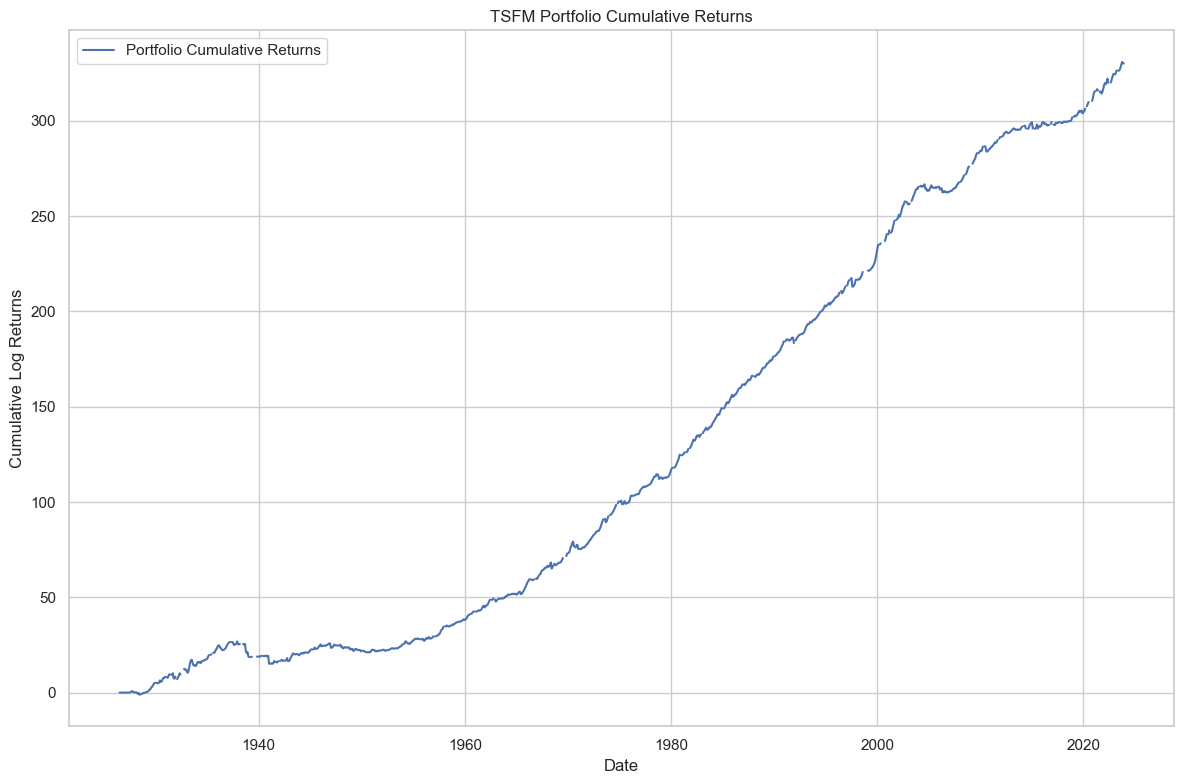

In [534]:
plot_cumulative_returns(sf_ls, log_return=True)

In [538]:
sf_ls

,mktrf,smb,hml,umd,age,...,z_score,zero_trades_126d,zero_trades_21d,zero_trades_252d,Total
1926-07-01,0.0000,0.0000,0.0000,0.0000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000
1926-08-01,0.0000,0.0000,0.0000,0.0000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000
1926-09-01,0.0000,0.0000,0.0000,0.0000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000
1926-10-01,0.0000,0.0000,0.0000,0.0000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000
1926-11-01,0.0000,0.0000,0.0000,0.0000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...
2023-08-01,-0.0239,0.0000,0.0000,-0.0377,0.054567,...,0.000000,0.000000,0.000000,0.000000,2.223551
2023-09-01,0.0000,0.0252,-0.0151,0.0000,0.033245,...,0.025393,0.047604,0.048954,0.044560,3.521955
2023-10-01,0.0000,0.0388,0.0000,0.0000,0.064723,...,0.041032,0.057859,0.045431,0.064437,4.070705
2023-11-01,0.0000,0.0001,0.0000,0.0000,-0.005834,...,-0.000372,-0.034014,-0.026700,-0.037080,-0.541349


In [542]:
portfolio_returns['ls_ind_factor'] = sf_ls['Total']

In [546]:
portfolio_returns[(1,1)]

1926-07-01    0.000000
1926-08-01    0.000000
1926-09-01    0.000000
1926-10-01    0.000000
1926-11-01    0.000000
                ...   
2023-08-01    0.002760
2023-09-01    0.000304
2023-10-01   -0.001093
2023-11-01   -0.004403
2023-12-01    0.000000
Freq: MS, Length: 1170, dtype: float64

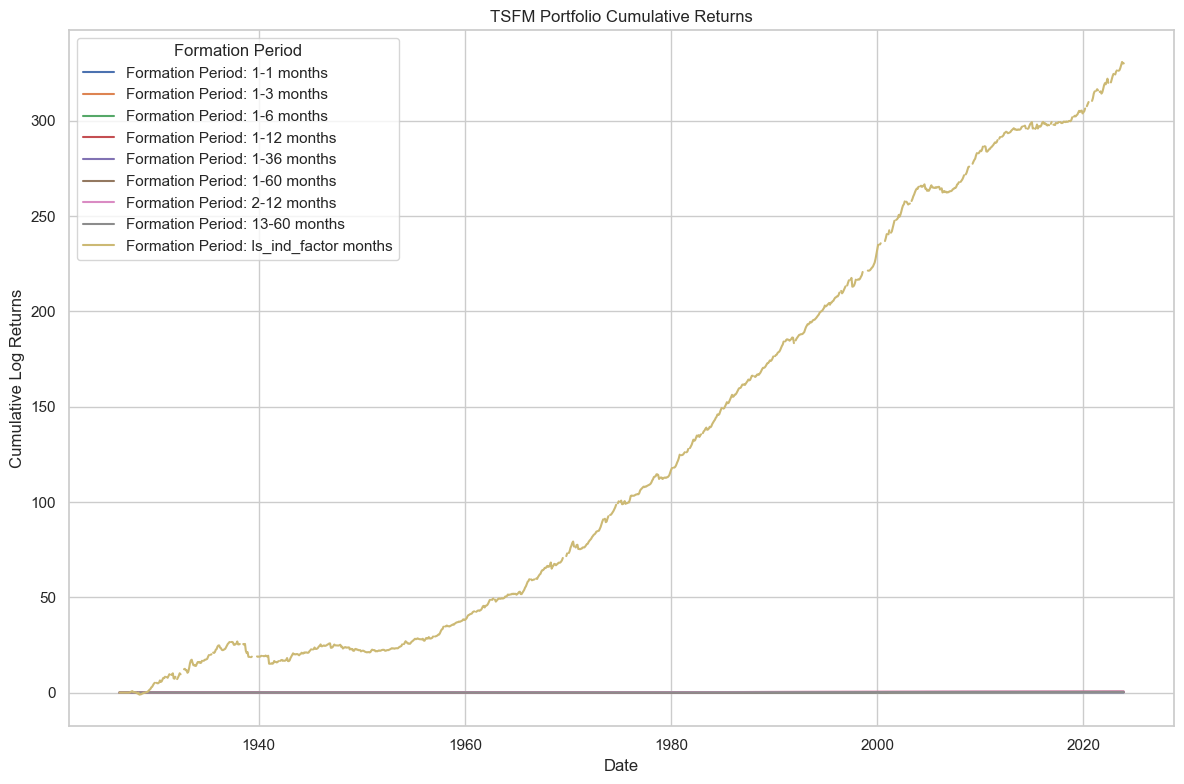

In [543]:
plot_portfolio_returns(portfolio_returns, log_return=True)

In [548]:
overall_returns['ls_ind_factor'] = portfolio_returns['ls_ind_factor']

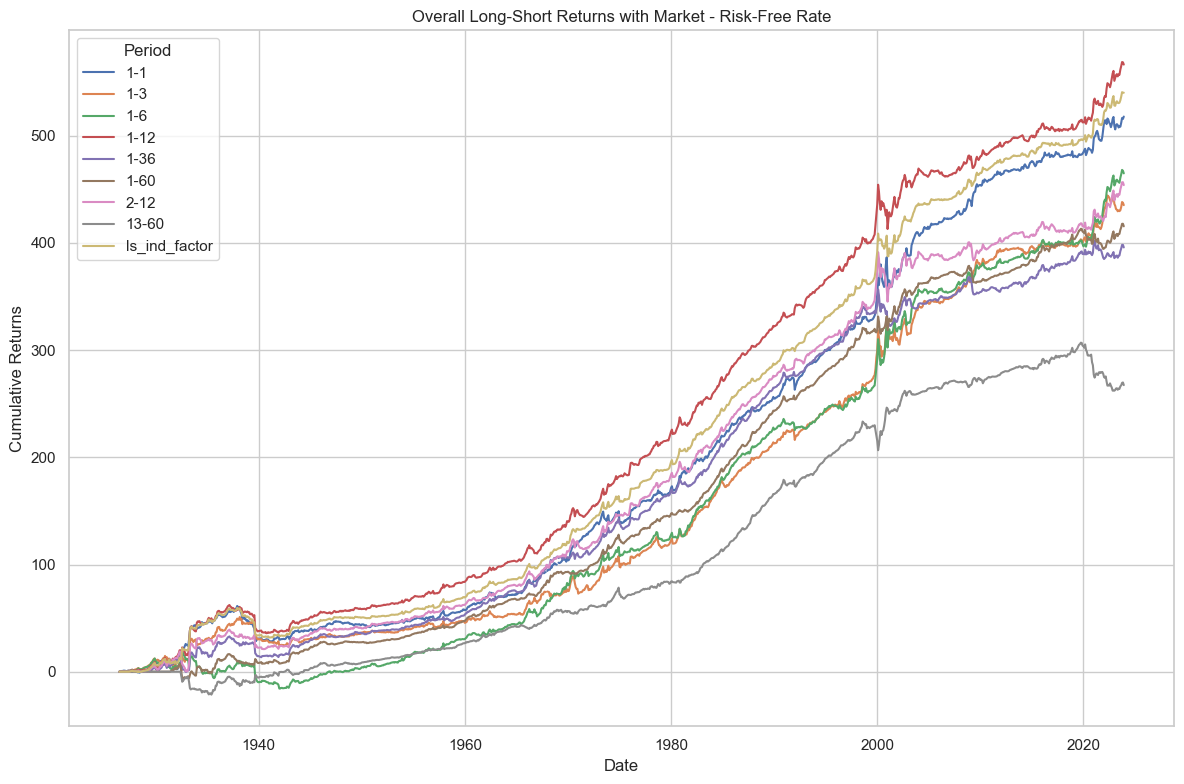

In [550]:
plot_overall_returns(overall_returns, None, output_path=None, show_plot=True, log_return=False)

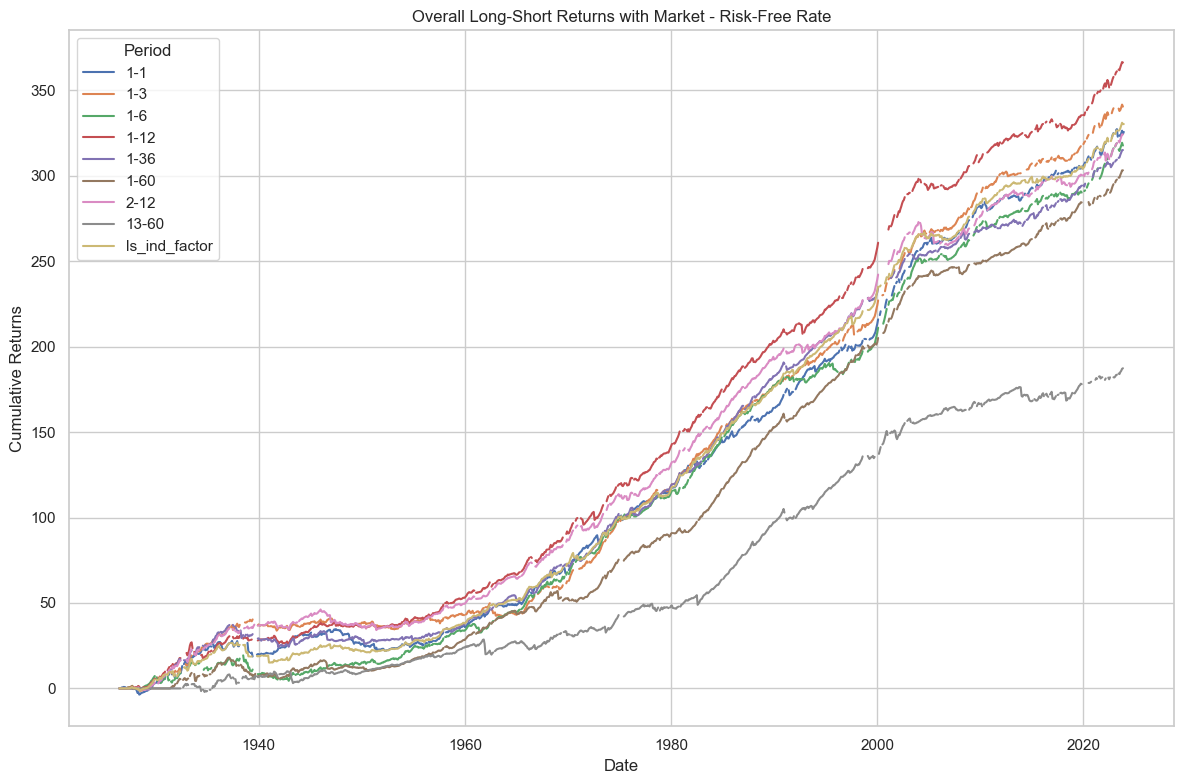

In [551]:
plot_overall_returns(overall_returns, None, output_path=None, show_plot=True, log_return=True)

# Turning points 2

In [498]:
usa_fac_ewm_r12 = pd.DataFrame(index=usa_fac_ewm.index)

for col in usa_fac_ewm.columns:
    usa_fac_ewm_r12[f'{col}_12m'] = usa_fac_ewm[col].shift(1).rolling(12).mean().astype(float)

In [499]:
usa_fac_ewm_r1 = pd.DataFrame(index=usa_fac_ewm.index)

for col in usa_fac_ewm.columns:
    usa_fac_ewm_r1[f'{col}_1m'] = usa_fac_ewm[col].shift(1).astype(float)

In [501]:
fms_s = pd.DataFrame(index=usa_fac_ewm.index)
fms_f = pd.DataFrame(index=usa_fac_ewm.index)
fms_s_ret = pd.DataFrame(index=usa_fac_ewm.index)
fms_f_ret = pd.DataFrame(index=usa_fac_ewm.index)

for col in usa_fac_ewm_r12.columns:
    fms_s[f'{col}'] = np.where(usa_fac_ewm_r12[col]>=0,1,-1)
for col in usa_fac_ewm_r1.columns:
    fms_f[f'{col}'] = np.where(usa_fac_ewm_r1[col]>=0,1,-1)


KeyError: 'mktrf'

In [515]:
fms_f

,mktrf_1m,smb_1m,hml_1m,umd_1m,age_1m,aliq_at_1m,aliq_mat_1m,ami_126d_1m,at_be_1m,at_gr1_1m,...,taccruals_at_1m,taccruals_ni_1m,tangibility_1m,tax_gr1a_1m,turnover_126d_1m,turnover_var_126d_1m,z_score_1m,zero_trades_126d_1m,zero_trades_21d_1m,zero_trades_252d_1m
1926-07-01,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,...,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1
1926-08-01,1,-1,-1,-1,1,-1,-1,-1,-1,-1,...,-1,-1,-1,-1,1,1,-1,-1,-1,-1
1926-09-01,1,-1,1,-1,1,-1,-1,1,-1,-1,...,-1,-1,-1,-1,1,-1,-1,1,1,1
1926-10-01,1,-1,1,-1,1,-1,-1,-1,-1,-1,...,-1,-1,-1,-1,1,-1,-1,1,1,1
1926-11-01,-1,-1,1,-1,-1,-1,-1,1,-1,-1,...,-1,-1,-1,-1,1,-1,-1,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-08-01,1,1,1,-1,-1,-1,-1,-1,-1,1,...,1,1,1,1,-1,1,-1,-1,-1,-1
2023-09-01,-1,-1,-1,1,-1,1,-1,-1,-1,-1,...,-1,1,-1,1,1,1,1,1,1,1
2023-10-01,-1,-1,1,1,-1,-1,-1,-1,-1,-1,...,-1,-1,1,1,1,1,1,1,1,1
2023-11-01,-1,-1,1,1,-1,1,-1,-1,-1,-1,...,-1,1,1,1,1,1,1,1,1,1


In [516]:
usa_fac_ewm

,mktrf,smb,hml,umd,age,aliq_at,aliq_mat,ami_126d,at_be,at_gr1,...,taccruals_at,taccruals_ni,tangibility,tax_gr1a,turnover_126d,turnover_var_126d,z_score,zero_trades_126d,zero_trades_21d,zero_trades_252d
1926-07-01,0.0296,-0.0256,-0.0243,NaN,0.017724,NaN,NaN,-0.016823,NaN,NaN,...,NaN,NaN,NaN,NaN,0.003053,0.022892,NaN,-0.002576,-0.010848,-0.003317
1926-08-01,0.0264,-0.0117,0.0382,NaN,0.006637,NaN,NaN,0.005364,NaN,NaN,...,NaN,NaN,NaN,NaN,0.009142,-0.004781,NaN,0.011396,0.016316,0.008391
1926-09-01,0.0036,-0.0140,0.0013,NaN,0.010408,NaN,NaN,-0.003075,NaN,NaN,...,NaN,NaN,NaN,NaN,0.023493,-0.017823,NaN,0.017074,0.014159,0.017161
1926-10-01,-0.0324,-0.0009,0.0070,NaN,-0.025142,NaN,NaN,0.003254,NaN,NaN,...,NaN,NaN,NaN,NaN,0.050600,-0.028641,NaN,0.021544,0.027053,0.019707
1926-11-01,0.0253,-0.0010,-0.0051,NaN,-0.020353,NaN,NaN,-0.015962,NaN,NaN,...,NaN,NaN,NaN,NaN,-0.022512,0.014341,NaN,-0.014314,-0.011220,-0.012692
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-08-01,-0.0239,-0.0316,-0.0106,0.0377,-0.054567,0.002399,-0.001066,-0.047448,-0.003451,-0.020061,...,-0.031117,0.003720,-0.008152,0.023259,0.074987,0.035290,0.050579,0.073846,0.075131,0.067512
2023-09-01,-0.0524,-0.0252,0.0151,0.0026,-0.033245,-0.012930,-0.018309,-0.022491,-0.011440,-0.017367,...,-0.034718,-0.000075,0.001992,0.000153,0.047818,0.022536,0.025393,0.047604,0.048954,0.044560
2023-10-01,-0.0319,-0.0388,0.0018,0.0172,-0.064723,0.011269,-0.003807,-0.045575,-0.031388,-0.013805,...,-0.022756,0.014109,0.007450,0.008461,0.058655,0.039382,0.041032,0.057859,0.045431,0.064437
2023-11-01,0.0884,-0.0001,0.0165,0.0276,0.005834,-0.017131,-0.016945,-0.024631,-0.018813,0.007285,...,0.018934,0.017655,0.012397,-0.014662,-0.031441,0.019183,-0.000372,-0.034014,-0.026700,-0.037080


# Factor ar

In [39]:
# Creating the lagged and rolling variables
usa_fac_ewm_r1 = pd.DataFrame(columns=usa_fac_ewm.columns, index=usa_fac_ewm.index)

for col in usa_fac_ewm.columns:
    usa_fac_ewm_r1[col] = usa_fac_ewm[col].shift(1).astype(float)

usa_fac_ewm_r12 = pd.DataFrame(columns=usa_fac_ewm.columns, index=usa_fac_ewm.index)

for col in usa_fac_ewm.columns:
    usa_fac_ewm_r12[col] = usa_fac_ewm[col].shift(1).rolling(12).mean().astype(float)

In [48]:
def compute_ar_coefficients(data, n):
    ar_coeffs = []
    ar_errors = []
    
    for column in data.columns:
        series = data[column].dropna()
        if len(series) > n:
            model = AutoReg(series, lags=n).fit()
            ar_coeffs.append(model.params[1:n+1])
            ar_errors.append(model.bse[1:n+1])
        else:
            ar_coeffs.append([np.nan] * n)
            ar_errors.append([np.nan] * n)
    
    return np.array(ar_coeffs), np.array(ar_errors)

In [49]:
ar1_coeffs, ar1_errors = compute_ar_coefficients(usa_fac_ewm, 1)

In [50]:
ar12_coeffs, ar12_errors = compute_ar_coefficients(usa_fac_ewm, 12)

In [43]:
def plot_ar_coefficients(factor_names, ar_coeffs, ar_errors, n, save_path=None, img_show=None):
    for i in range(n):
        coeffs = ar_coeffs[:, i]
        errors = ar_errors[:, i]
        
        results_df = pd.DataFrame({
            'Factor': factor_names,
            f'AR({i+1})_Coefficient': coeffs,
            f'AR({i+1})_Standard_Error': errors
        })
        
        # Sort the DataFrame by AR(n) coefficient
        results_df = results_df.sort_values(by=f'AR({i+1})_Coefficient')
        
        plt.figure(figsize=(14, 8))
        sns.barplot(x='Factor', y=f'AR({i+1})_Coefficient', data=results_df, color='gray', ci=None)
        plt.errorbar(x=range(len(results_df)), y=results_df[f'AR({i+1})_Coefficient'], 
                     yerr=results_df[f'AR({i+1})_Standard_Error'], fmt='none', c='black', capsize=5)
        
        plt.xticks(rotation=90)
        plt.xlabel('Factor')
        plt.ylabel(f'AR({i+1}) Coefficient')
        plt.title(f'Factor Return Monthly AR({i+1}) Coefficients')
        plt.grid(True, axis='y', linestyle='--', alpha=0.7)
        plt.tight_layout()
        
        if save_path:
            plt.savefig(f'{save_path}_AR{i+1}.png', bbox_inches='tight')
        if img_show:
            plt.show()
            
        plt.clf()
        plt.close()

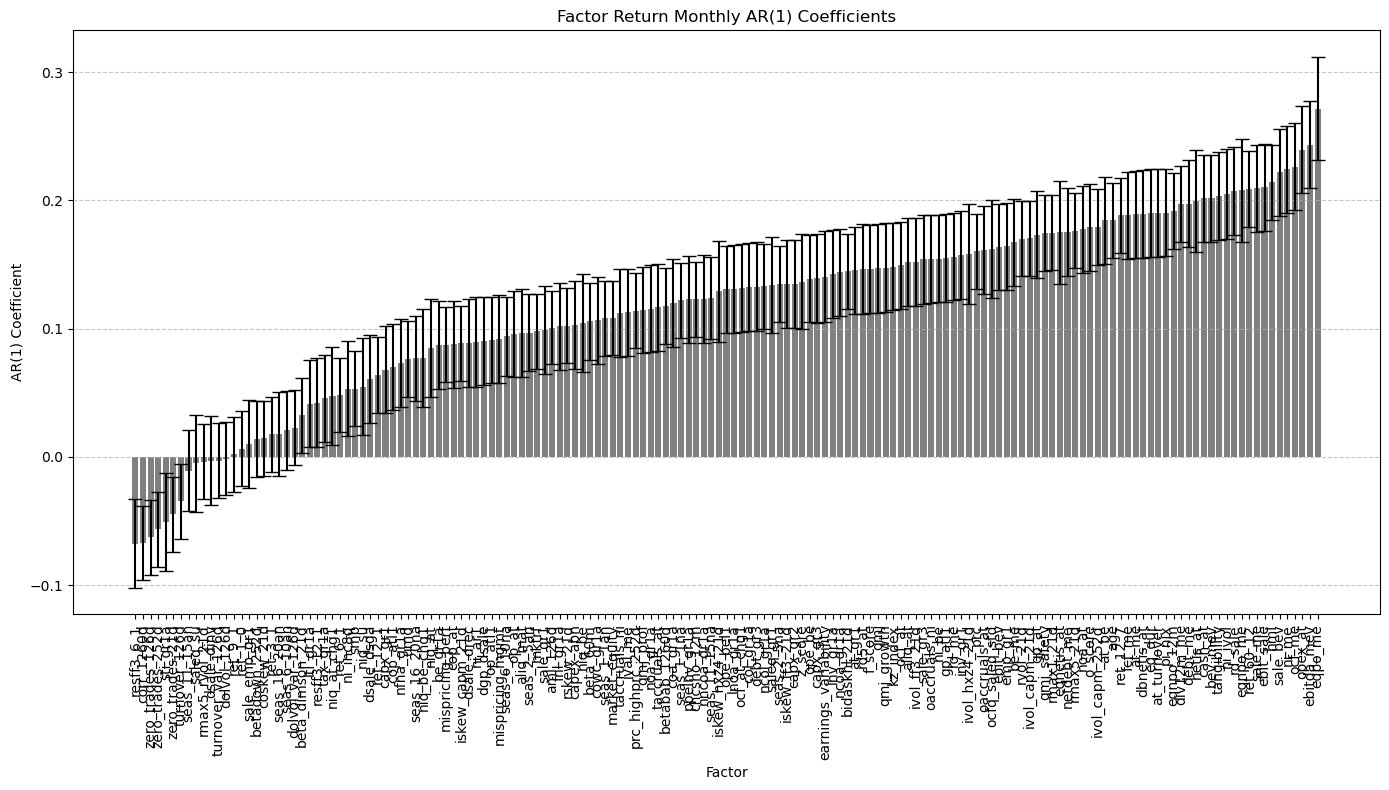

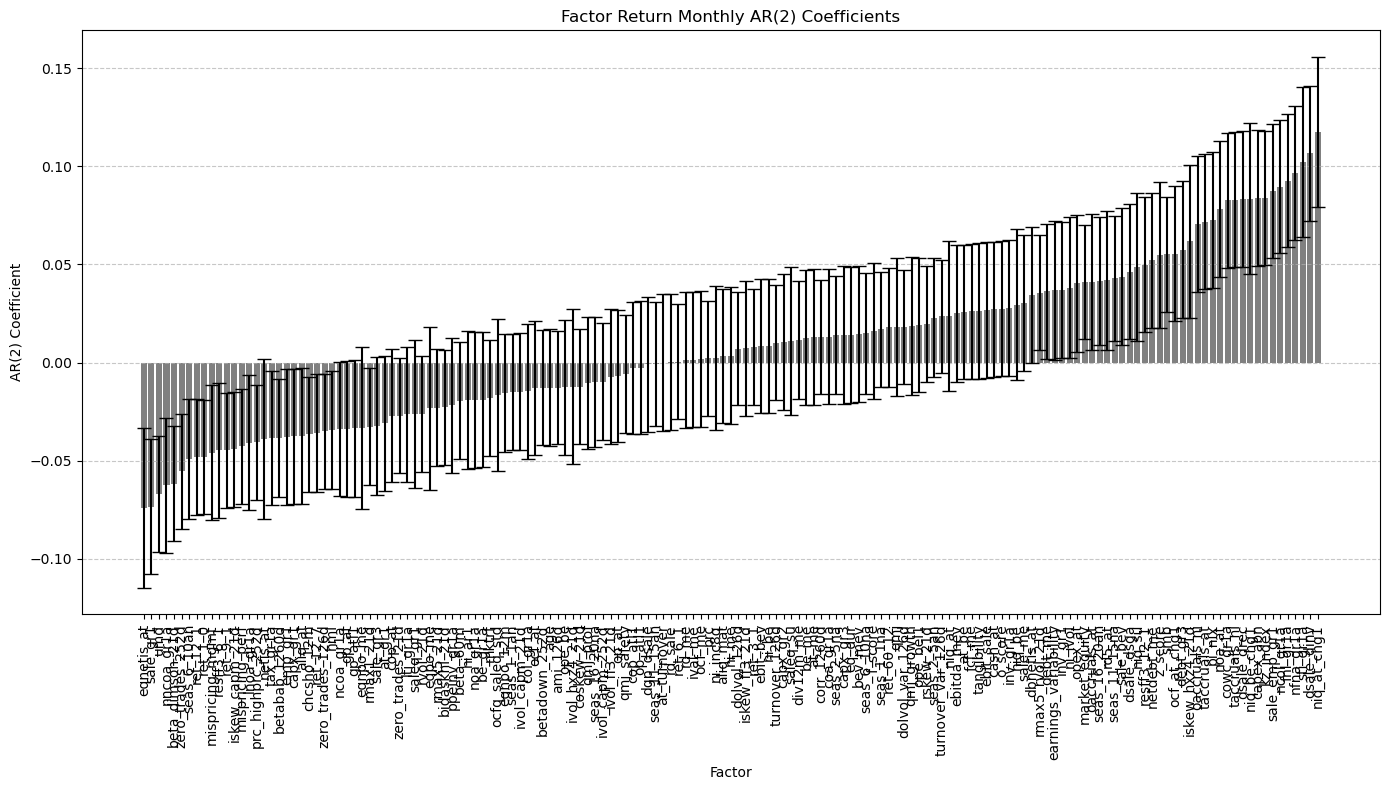

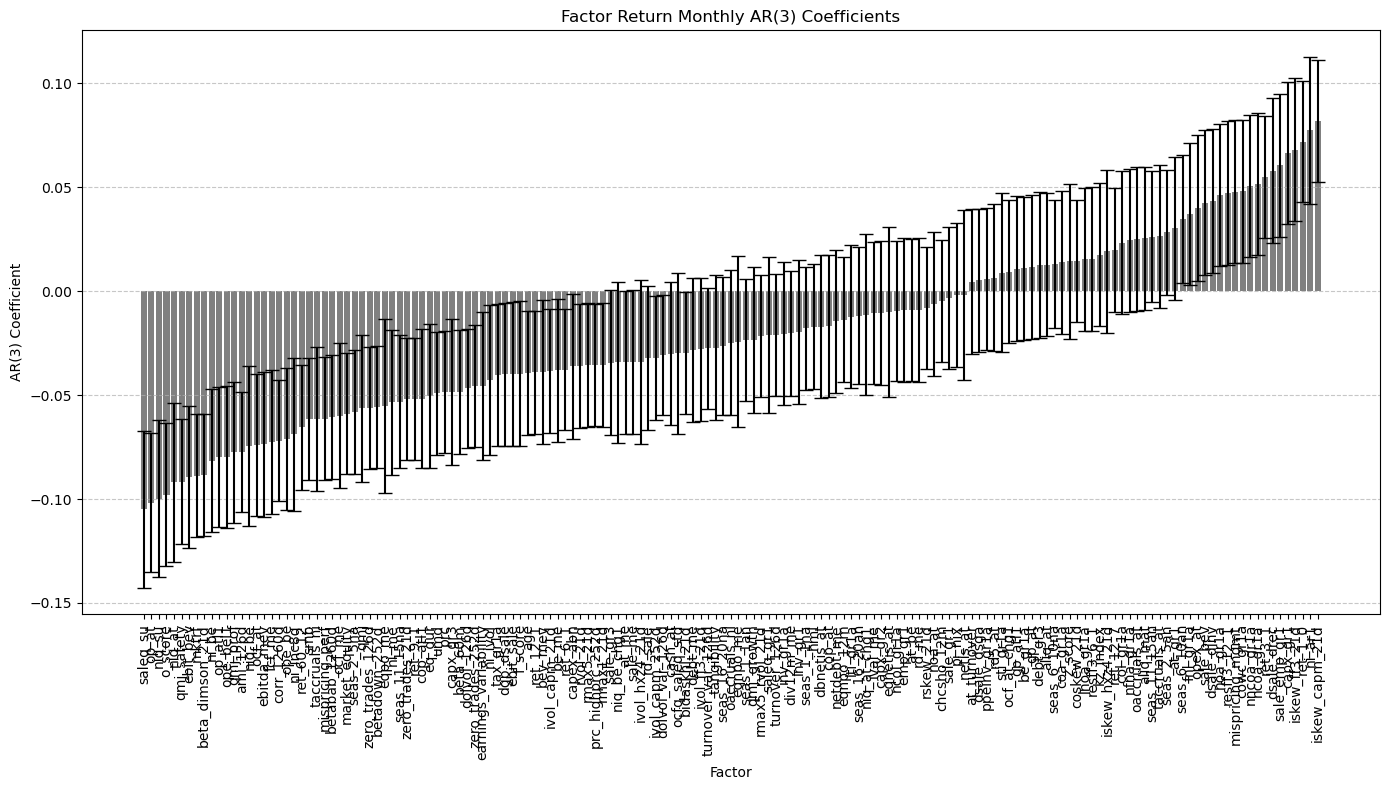

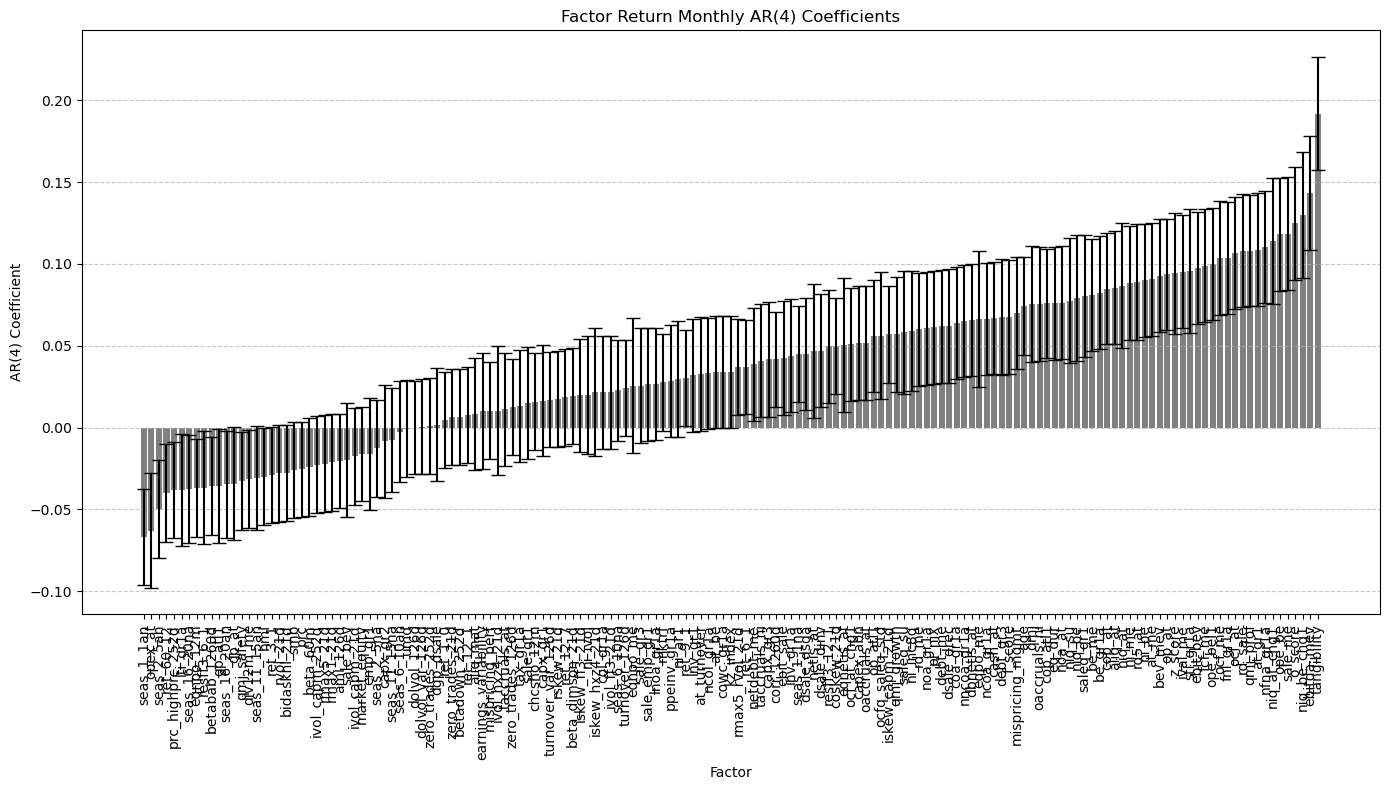

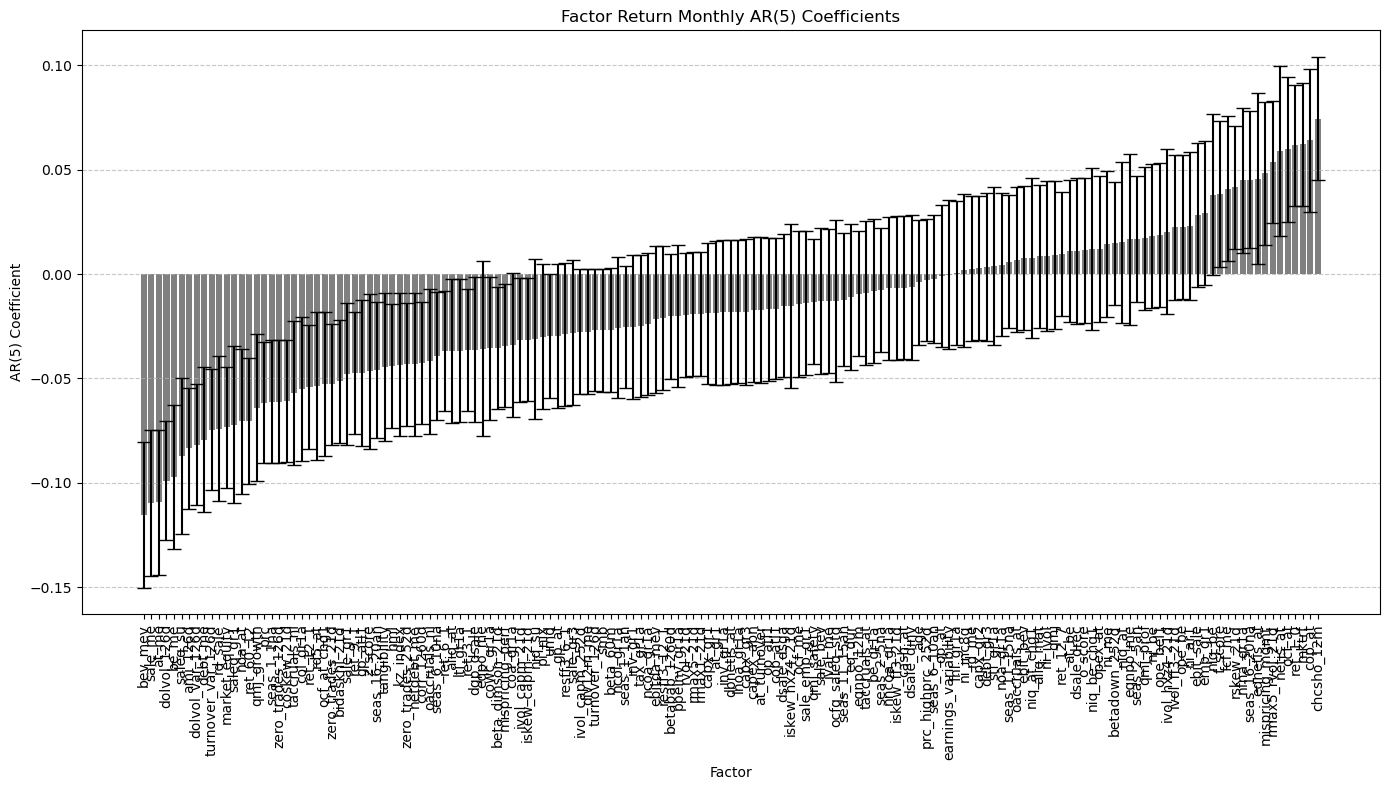

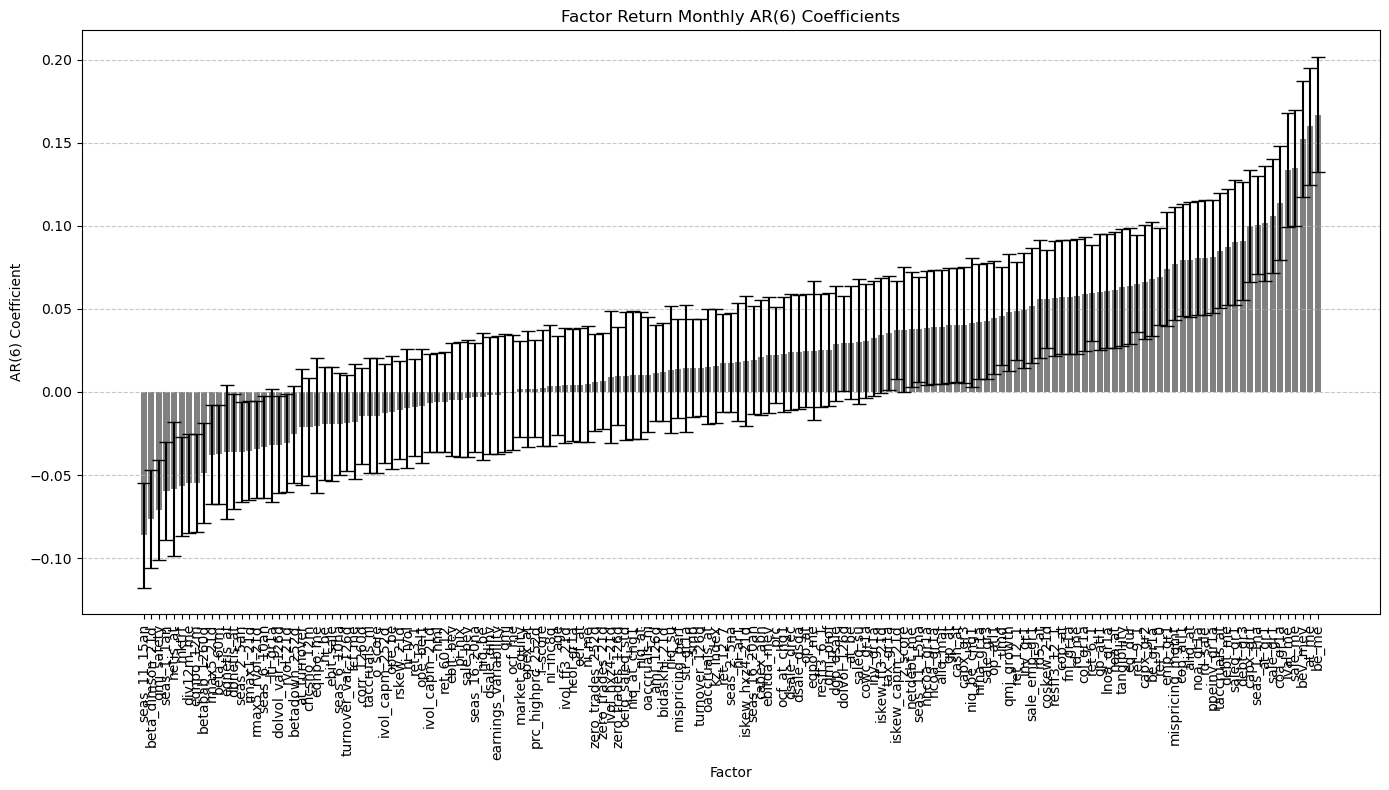

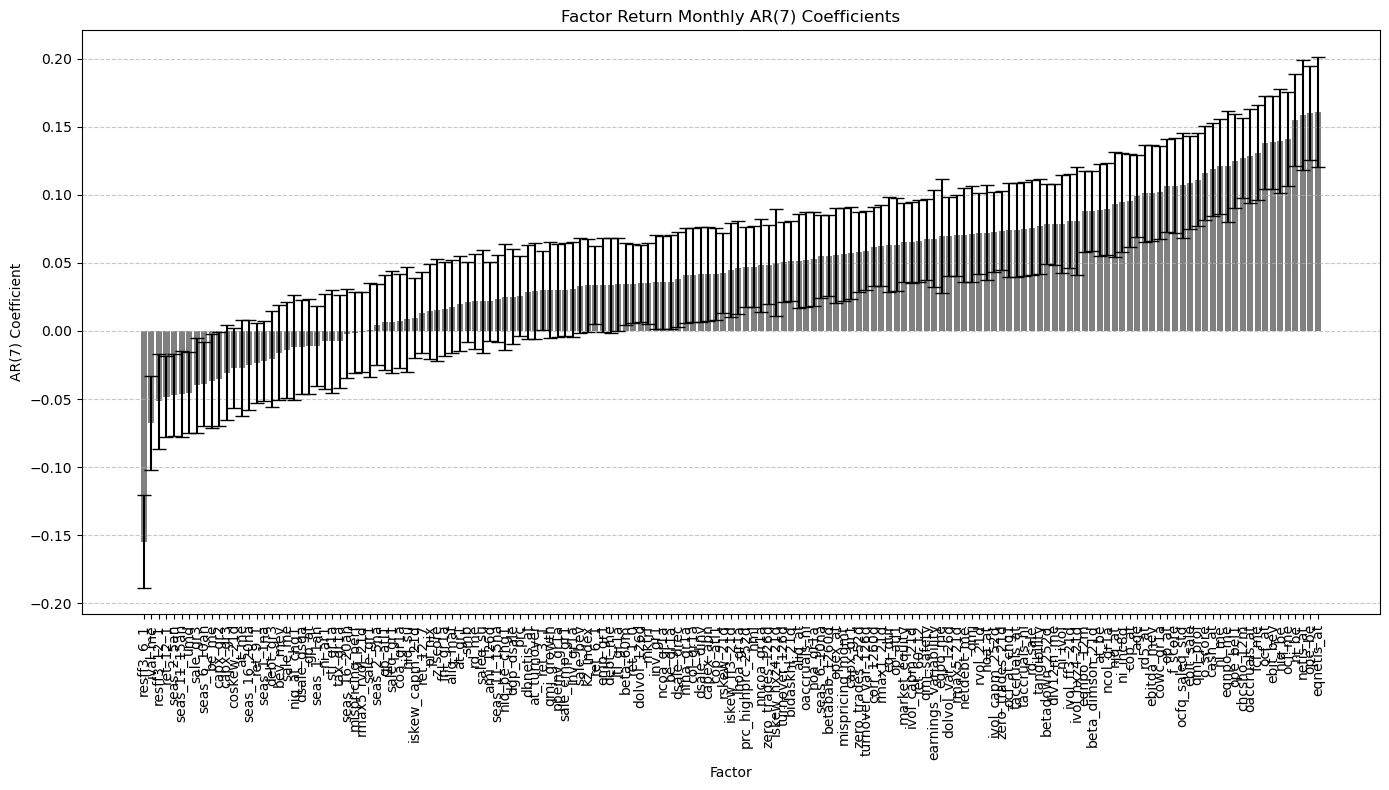

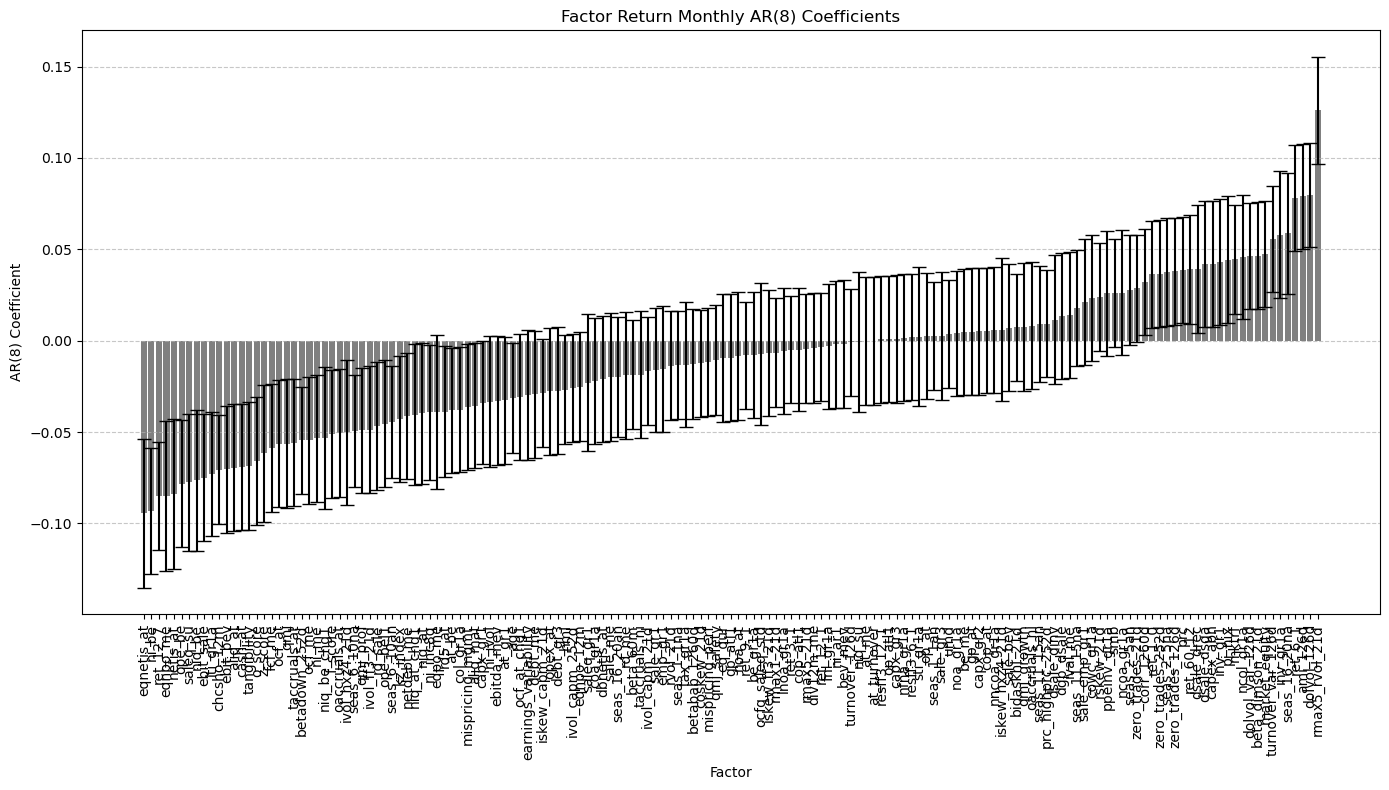

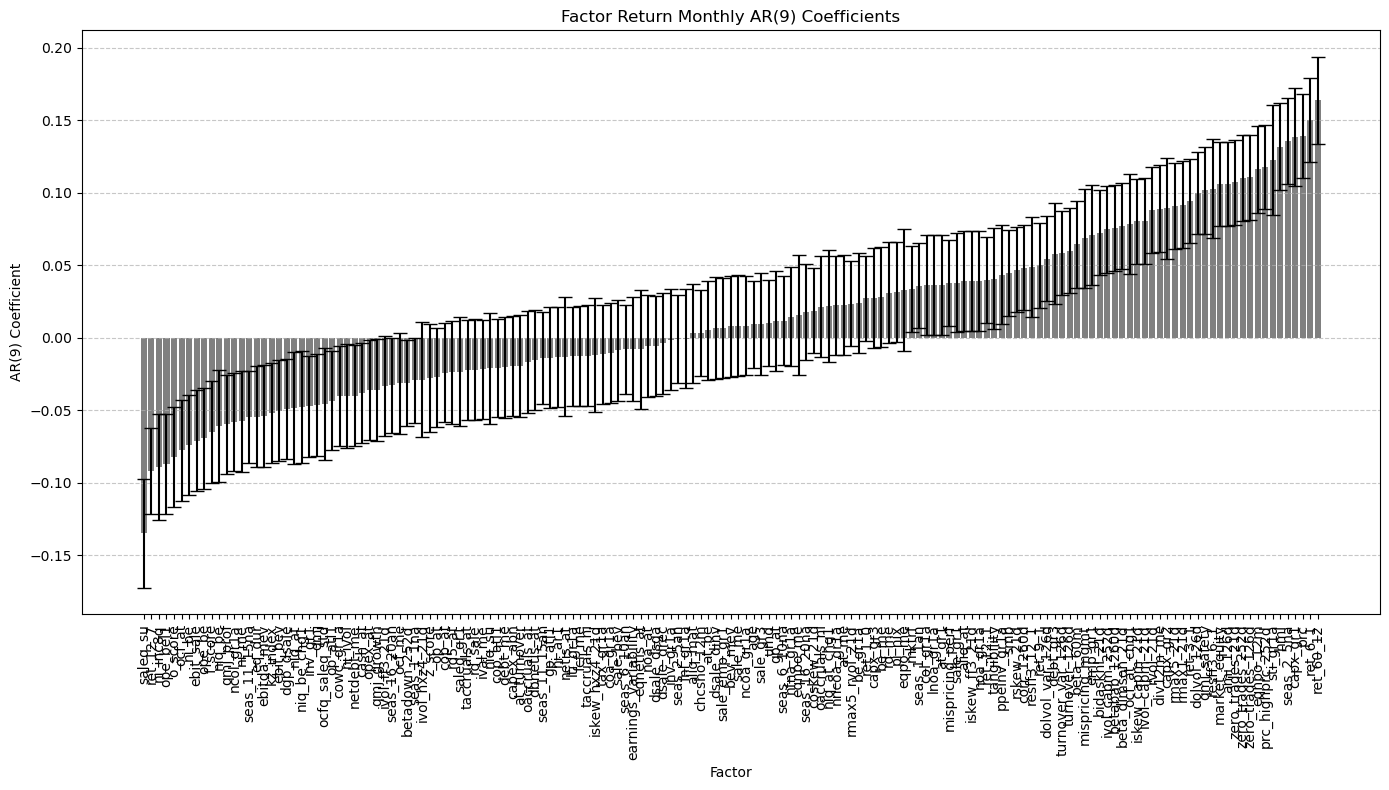

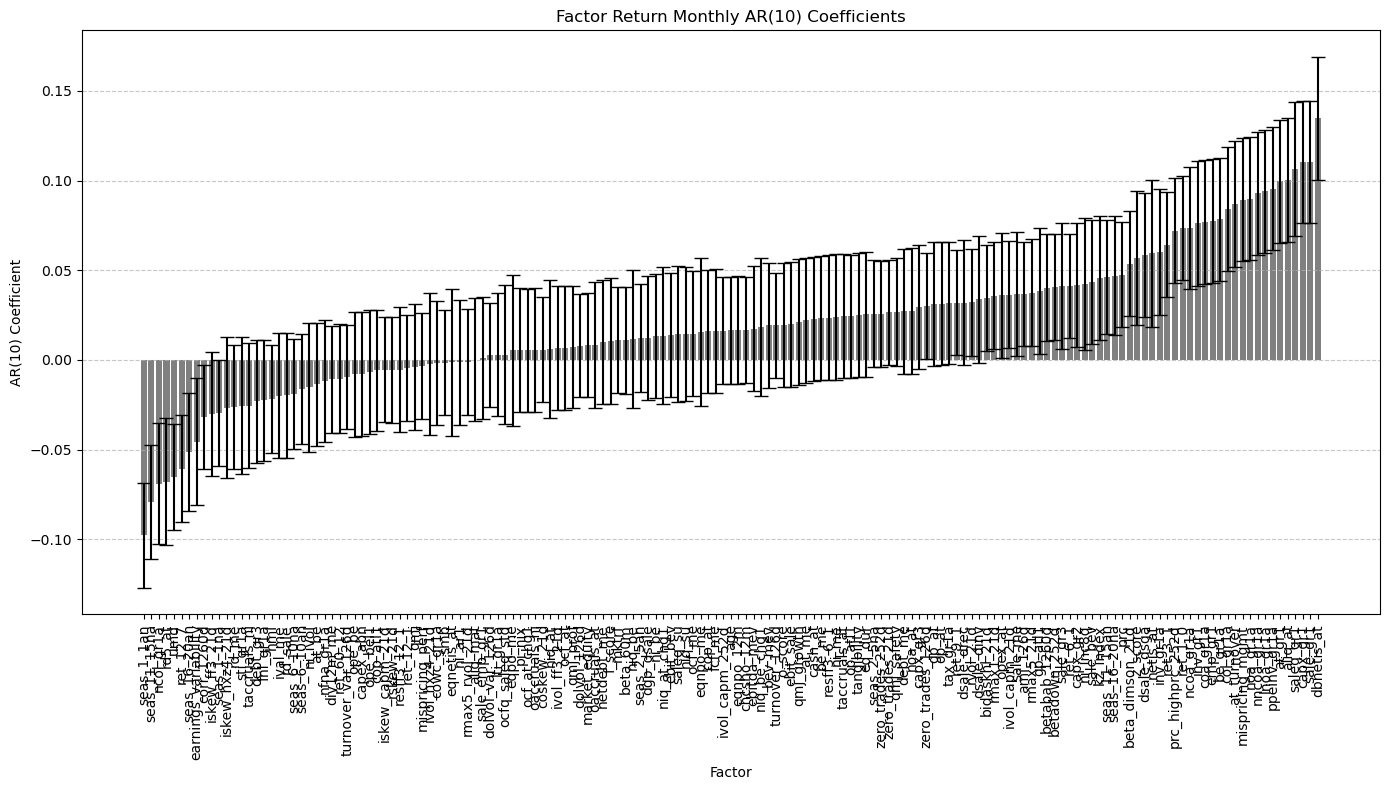

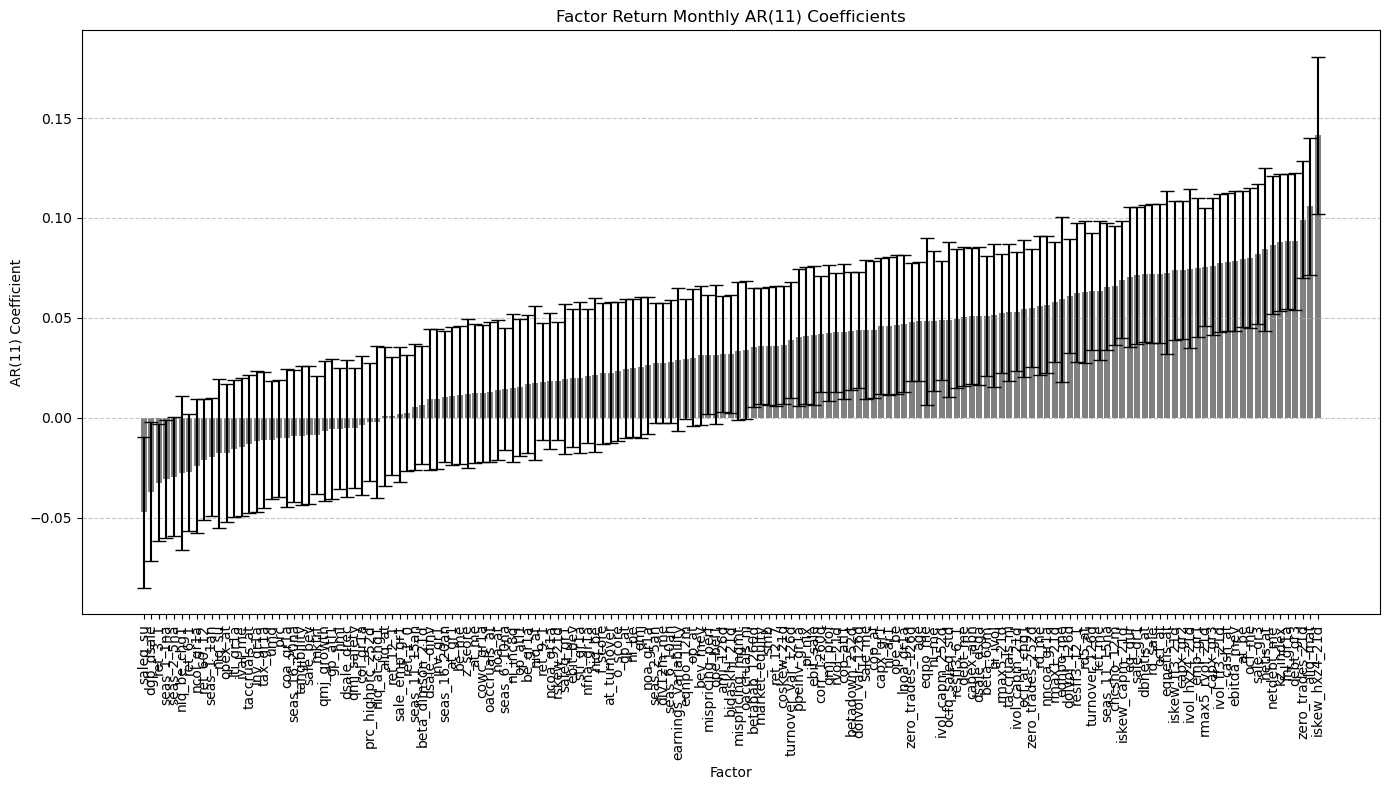

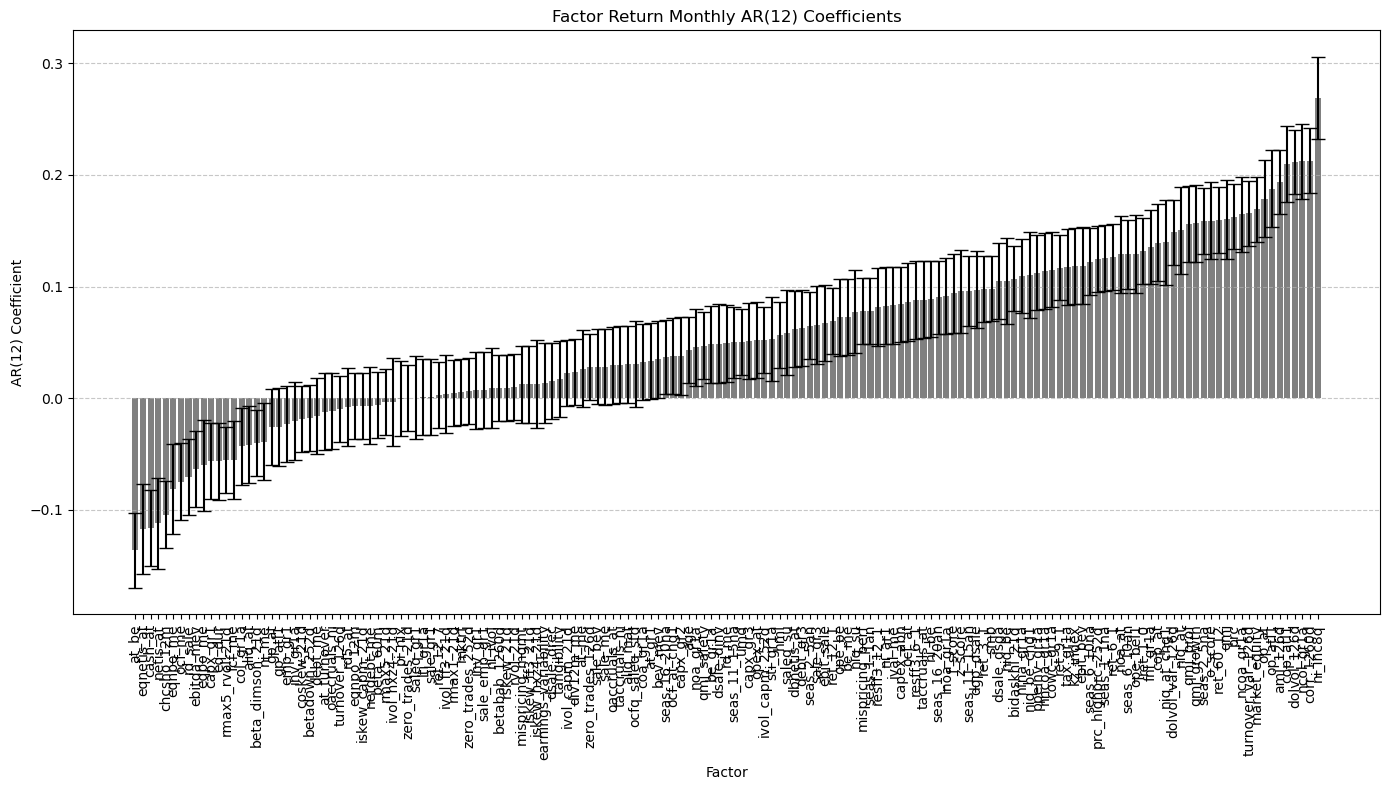

In [51]:
plot_ar_coefficients(usa_fac_ewm.columns, ar12_coeffs, ar12_errors, 12, img_show=True)

In [56]:
def filter_significant_factors(data, n, t_threshold=2.00):
    ar_coeffs, ar_errors = compute_ar_coefficients(data, n)
    
    significant_factors = {}
    for i, column in enumerate(data.columns):
        t_values = np.abs(ar_coeffs[i] / ar_errors[i])
        significant_indices = t_values >= t_threshold
        significant_coeffs = ar_coeffs[i][significant_indices]
        
        if significant_coeffs.size > 0:
            significant_factors[column] = significant_coeffs
    
    return significant_factors

In [61]:
sfactor_12 = filter_significant_factors(usa_fac_ewm, 1)

In [64]:
def report_significant_factors_across_ar_models(data, max_n, t_threshold=2.00):
    significant_factors_by_n = {}

    for n in range(1, max_n + 1):
        significant_factors = filter_significant_factors(data, n, t_threshold)
        significant_factors_by_n[n] = significant_factors
    
    return significant_factors_by_n

In [65]:
report_significant_factors_across_ar_models(usa_fac_ewm, 12)

{1: {'mktrf': array([0.09429763]),
  'smb': array([0.06180813]),
  'hml': array([0.20604137]),
  'umd': array([0.07182998]),
  'age': array([0.18312168]),
  'aliq_at': array([0.14502433]),
  'aliq_mat': array([0.10249431]),
  'ami_126d': array([0.1311404]),
  'at_be': array([0.18331762]),
  'at_gr1': array([0.16236995]),
  'at_me': array([0.16778968]),
  'at_turnover': array([0.19126162]),
  'be_gr1a': array([0.09902452]),
  'be_me': array([0.14691367]),
  'beta_60m': array([0.10952771]),
  'betabab_1260d': array([0.12143599]),
  'bev_mev': array([0.18412504]),
  'bidaskhl_21d': array([0.15693323]),
  'capex_abn': array([0.11380836]),
  'capx_gr1': array([0.0894112]),
  'capx_gr2': array([0.14748892]),
  'capx_gr3': array([0.15372255]),
  'cash_at': array([0.198349]),
  'chcsho_12m': array([0.11062188]),
  'coa_gr1a': array([0.11767387]),
  'col_gr1a': array([0.12973676]),
  'cop_at': array([0.12458274]),
  'cop_atl1': array([0.08408932]),
  'corr_1260d': array([-0.06038027]),
  'cowc_

In [77]:
def plot_significant_factors_across_ar_models(significant_factors_across_models, max_n, save_path=None, img_show=False):
    for n in range(1, max_n + 1):
        significant_factors = significant_factors_across_models.get(n, {})
        
        if not significant_factors:
            continue
        
        factors = []
        coeffs = []
        for factor, coeff_array in significant_factors.items():
            factors.append(factor)
            coeffs.append(coeff_array[0])  # Assume we only have one coefficient per factor
        
        results_df = pd.DataFrame({
            'Factor': factors,
            f'AR({n})_Coefficient': coeffs
        }).sort_values(by=f'AR({n})_Coefficient')
        
        plt.figure(figsize=(14, 8))
        sns.barplot(x='Factor', y=f'AR({n})_Coefficient', data=results_df, color='gray', ci=None)
        
        plt.xticks(rotation=90)
        plt.xlabel('Factor')
        plt.ylabel(f'AR({n}) Coefficient')
        plt.title(f'Factor Return Monthly AR({n}) Coefficients')
        plt.grid(True, axis='y', linestyle='--', alpha=0.7)
        plt.tight_layout()
        
        if save_path:
            plt.savefig(f'{save_path}_AR{n}.png', bbox_inches='tight')
        
        if img_show:
            plt.show()
        plt.clf()
        plt.close()

In [78]:
s_factor_1_12 = report_significant_factors_across_ar_models(usa_fac_ewm, 12)

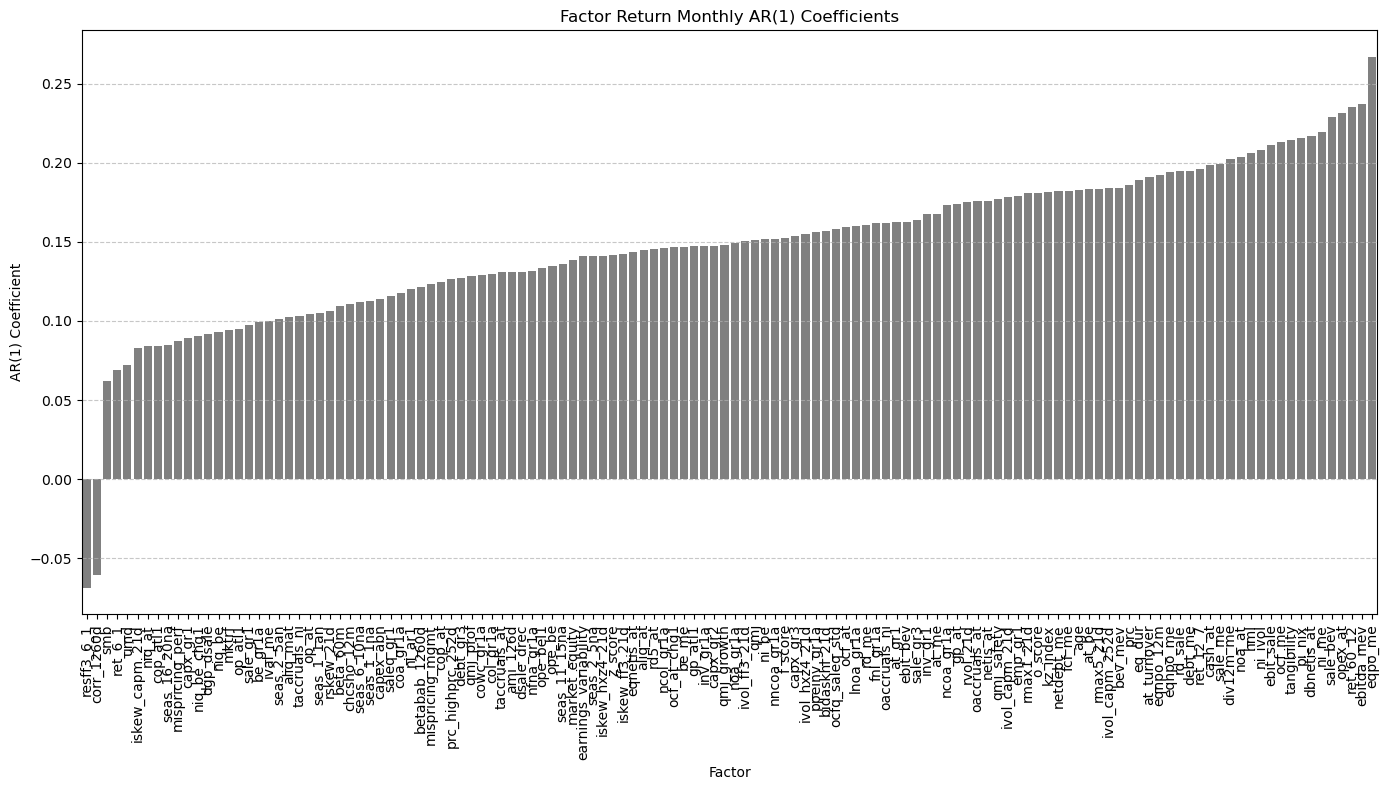

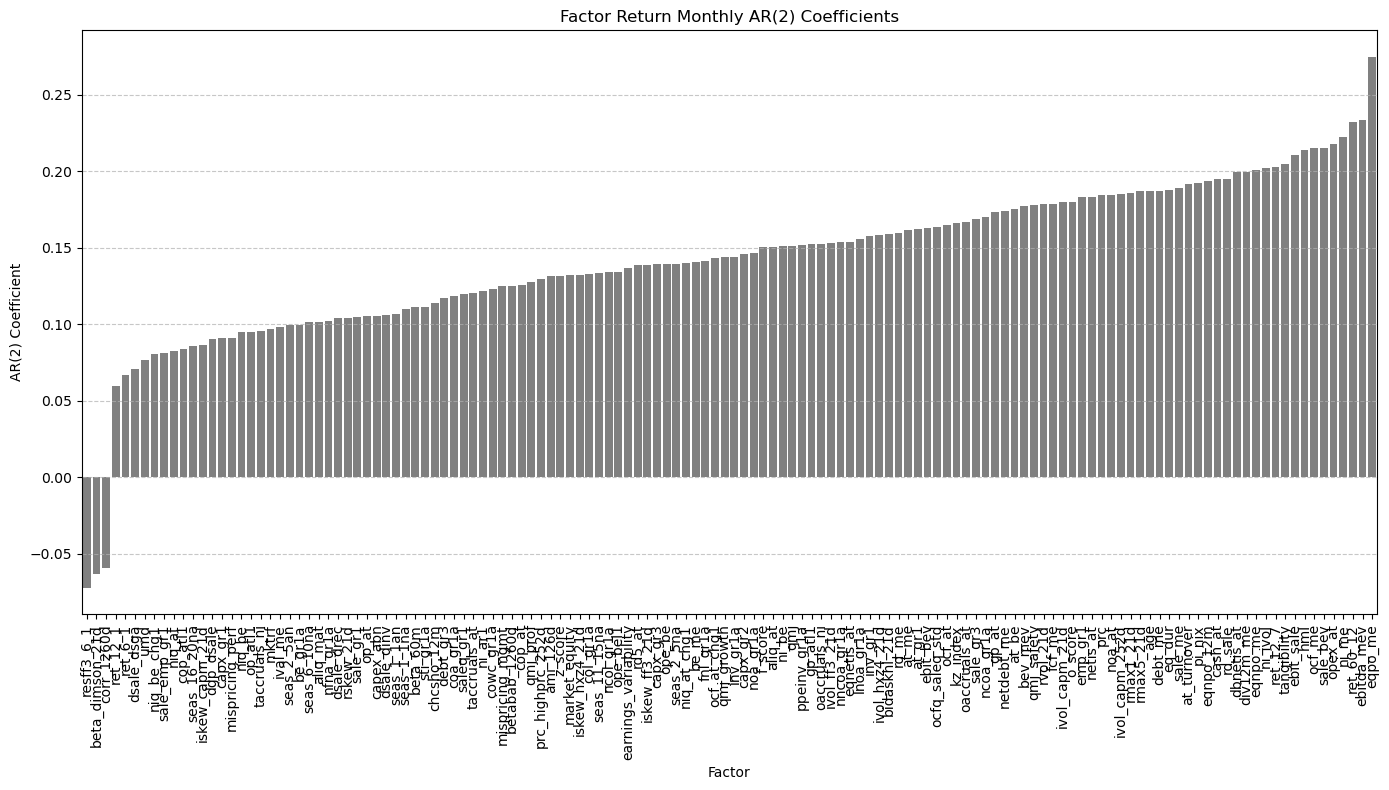

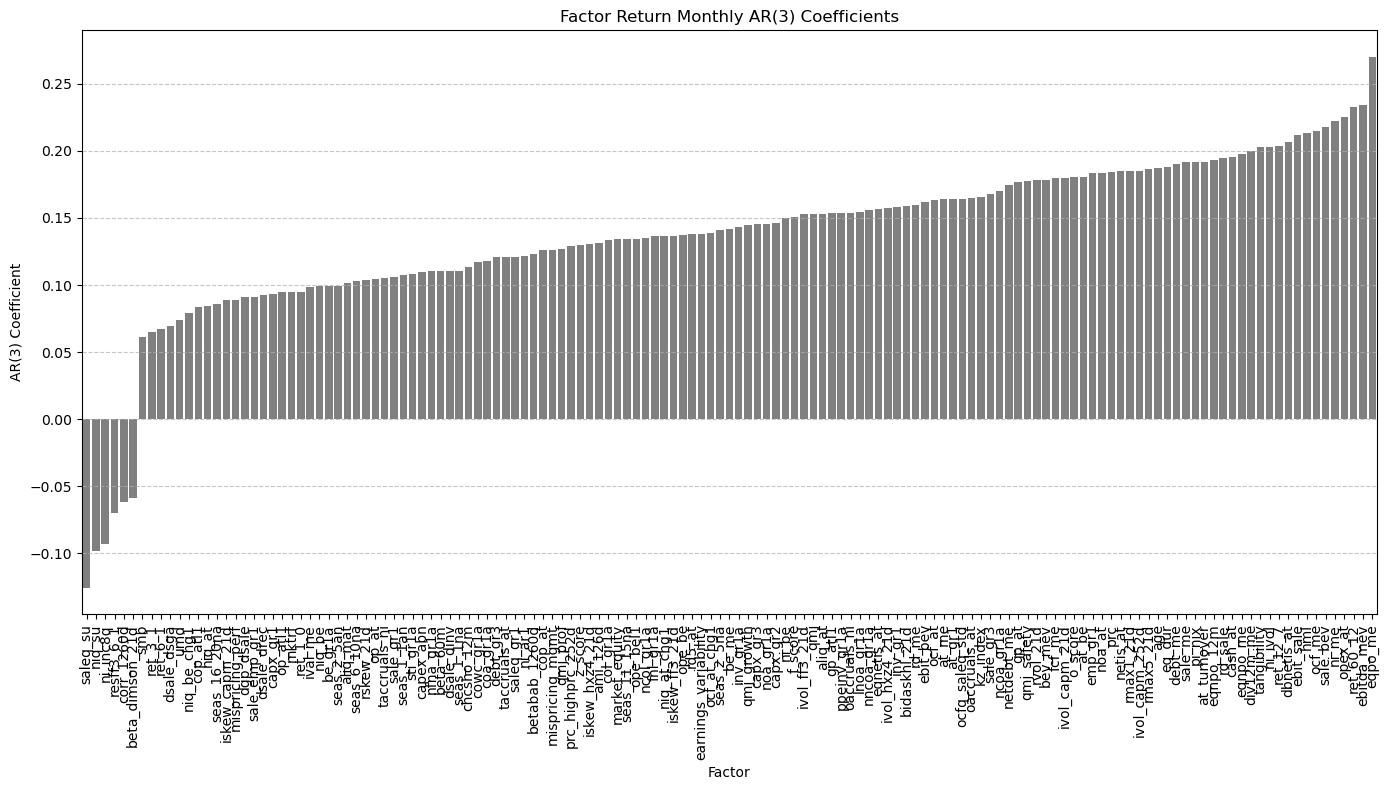

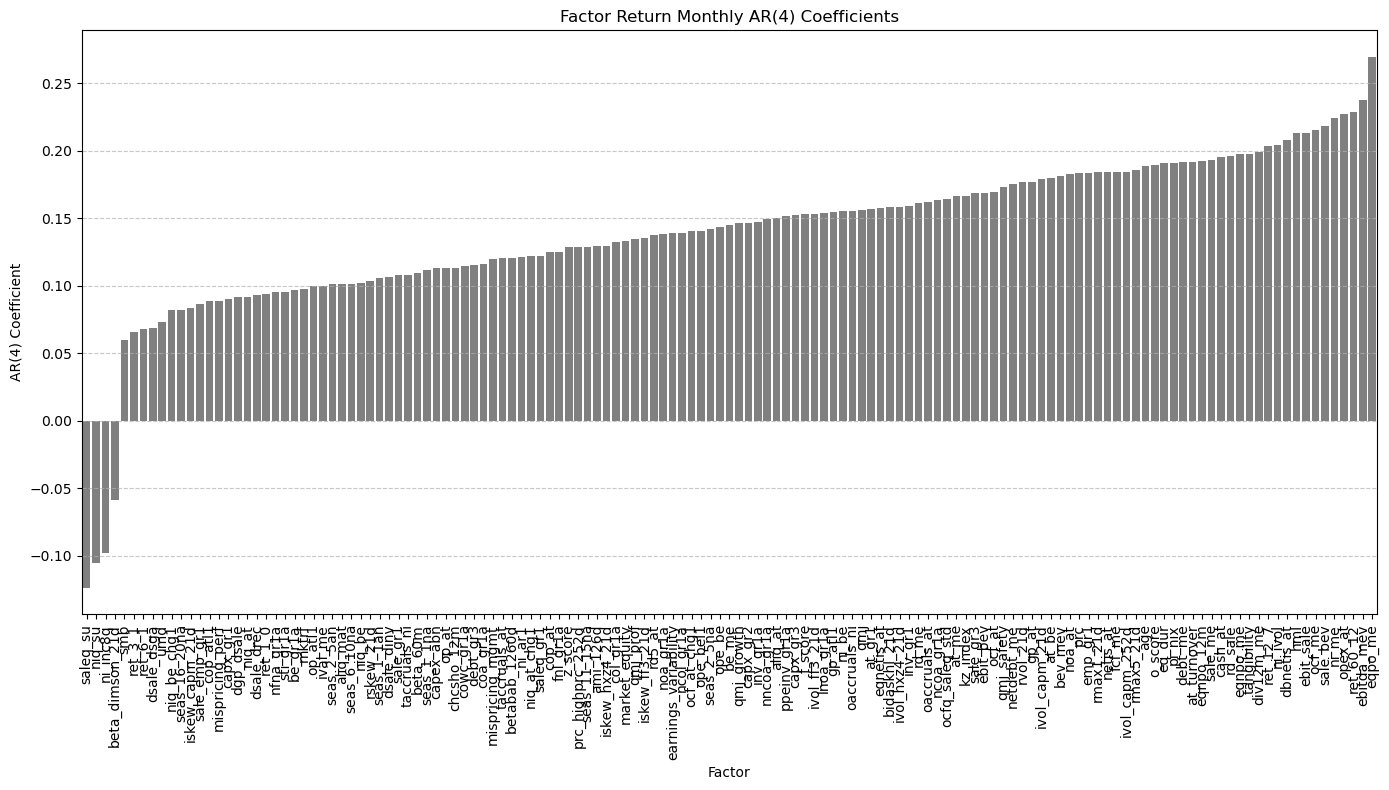

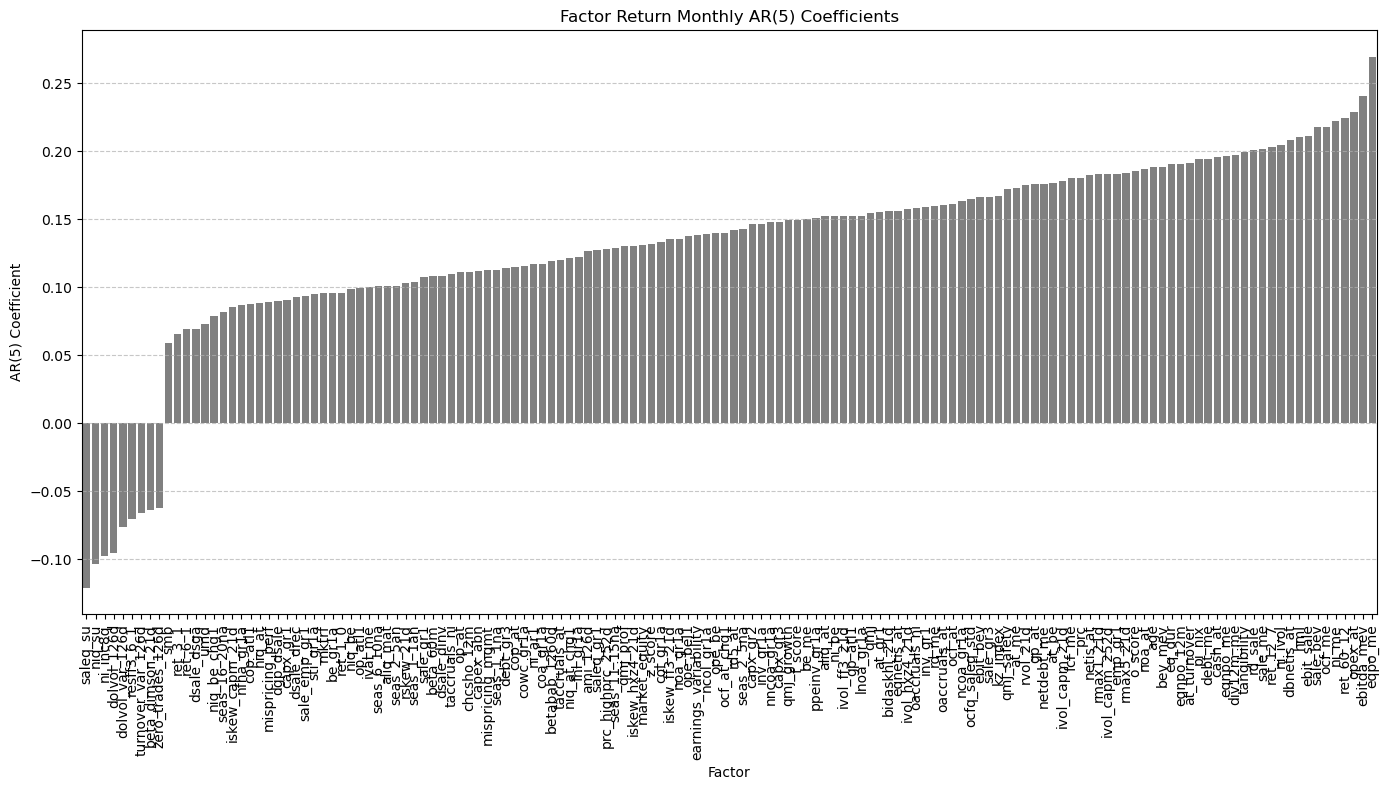

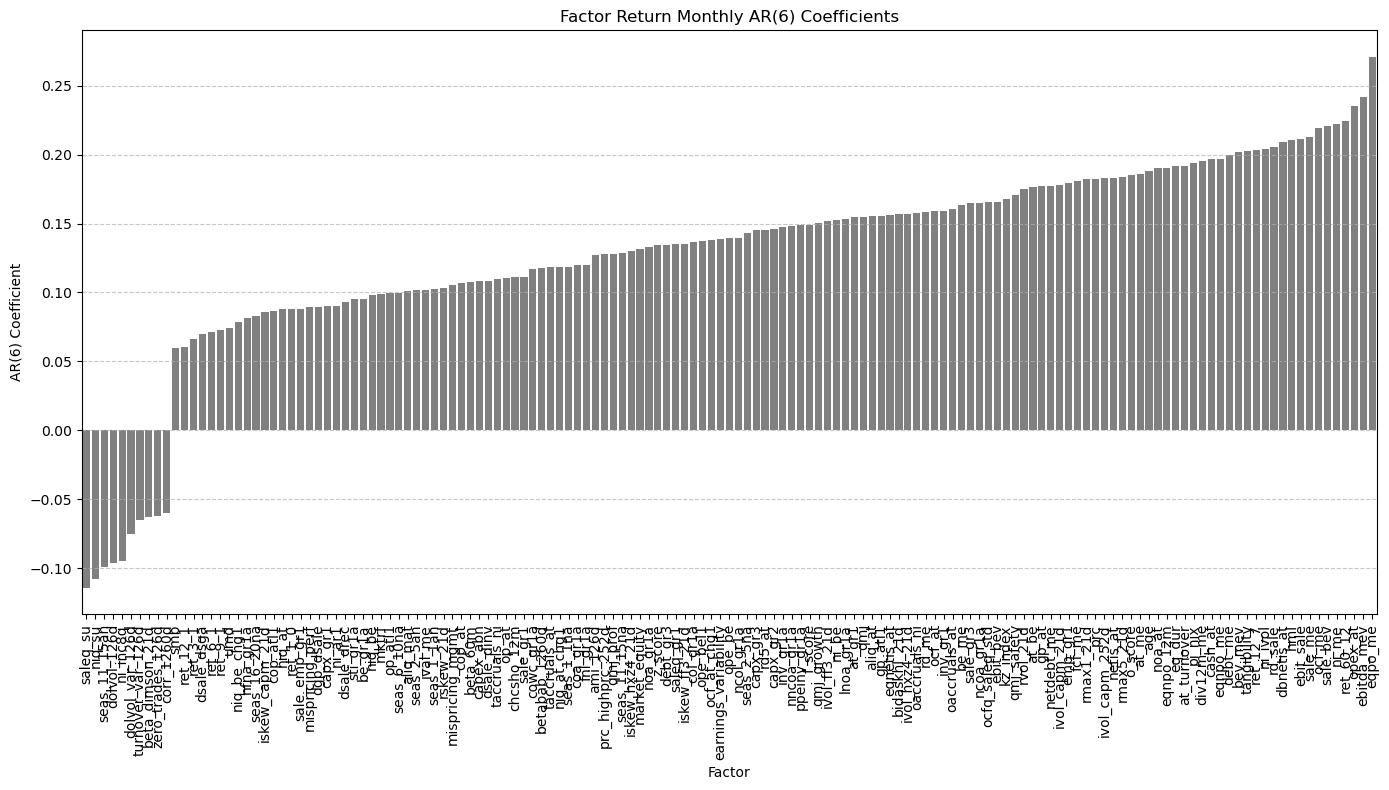

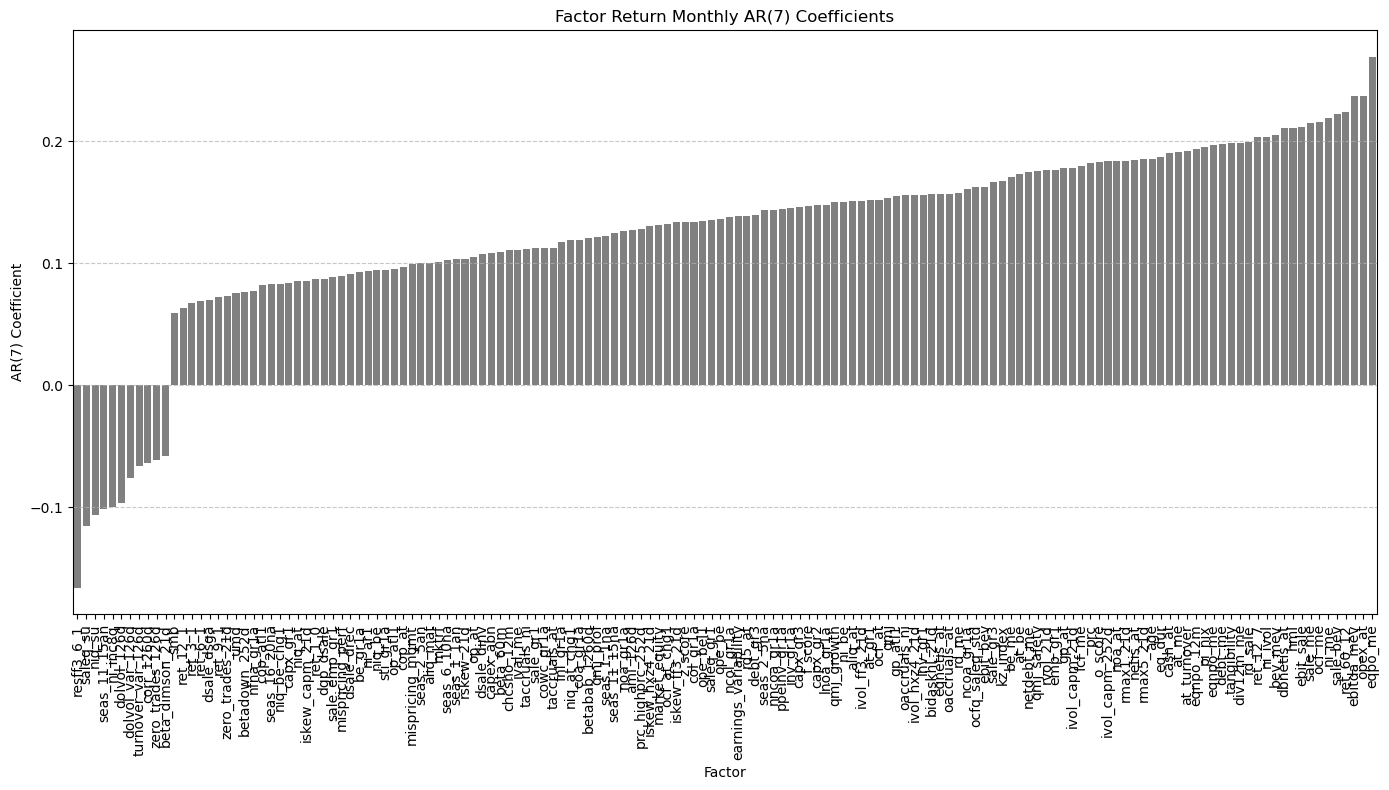

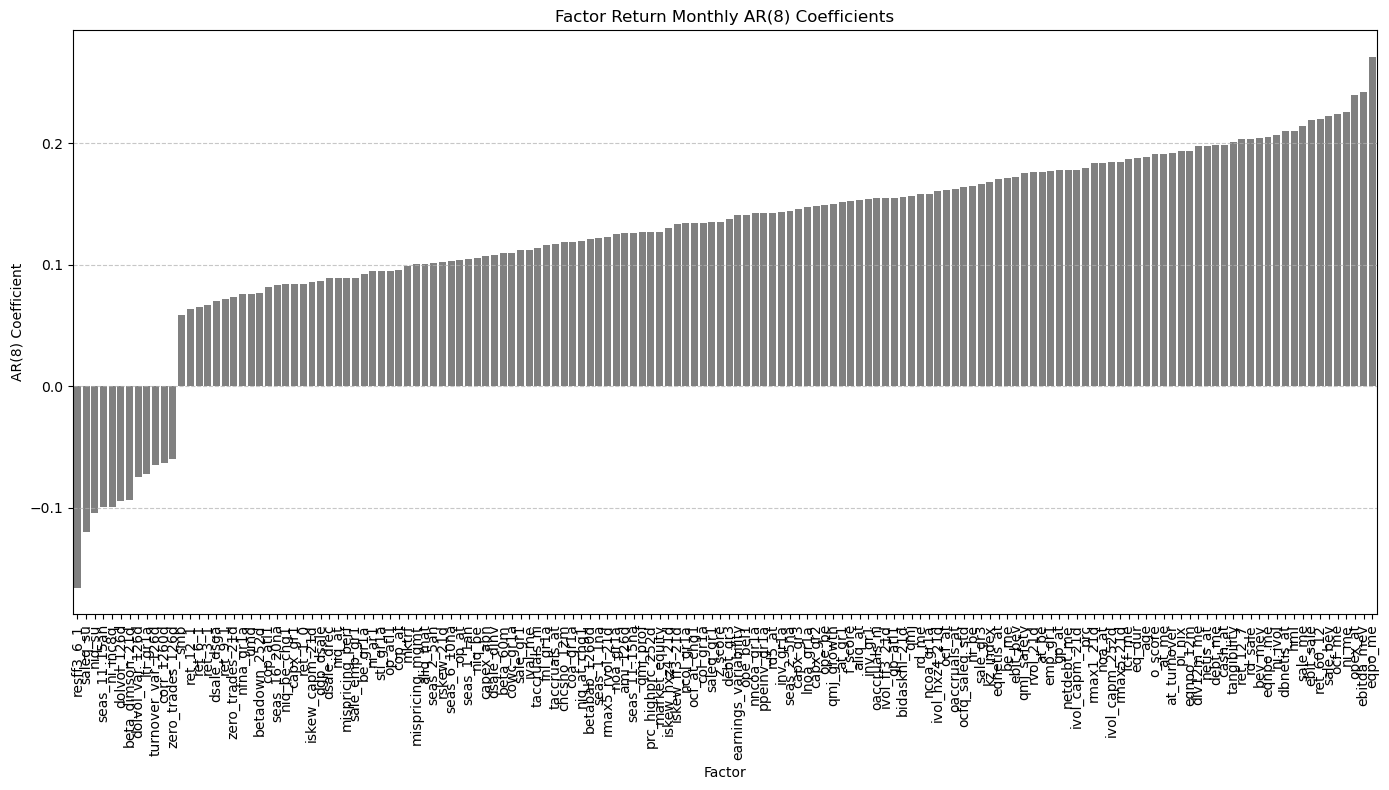

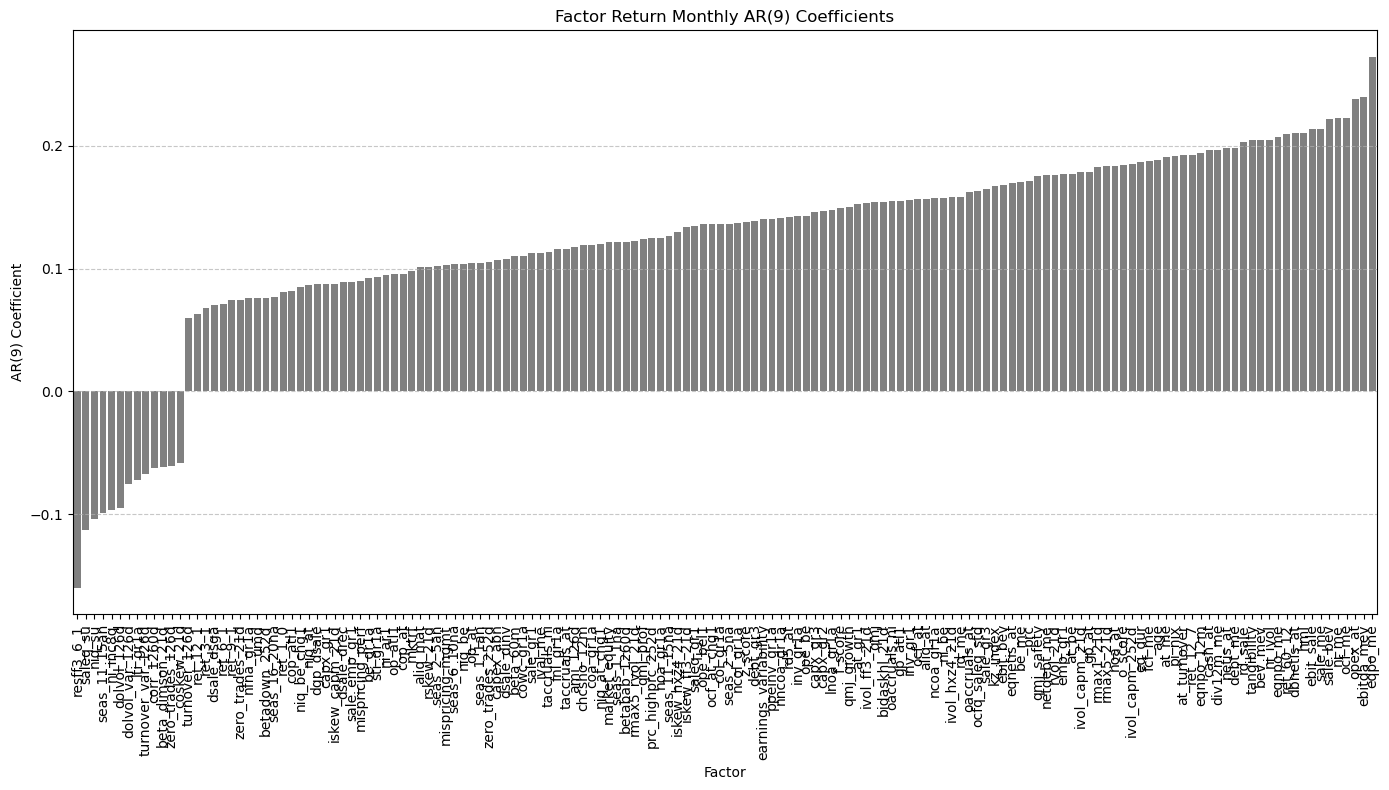

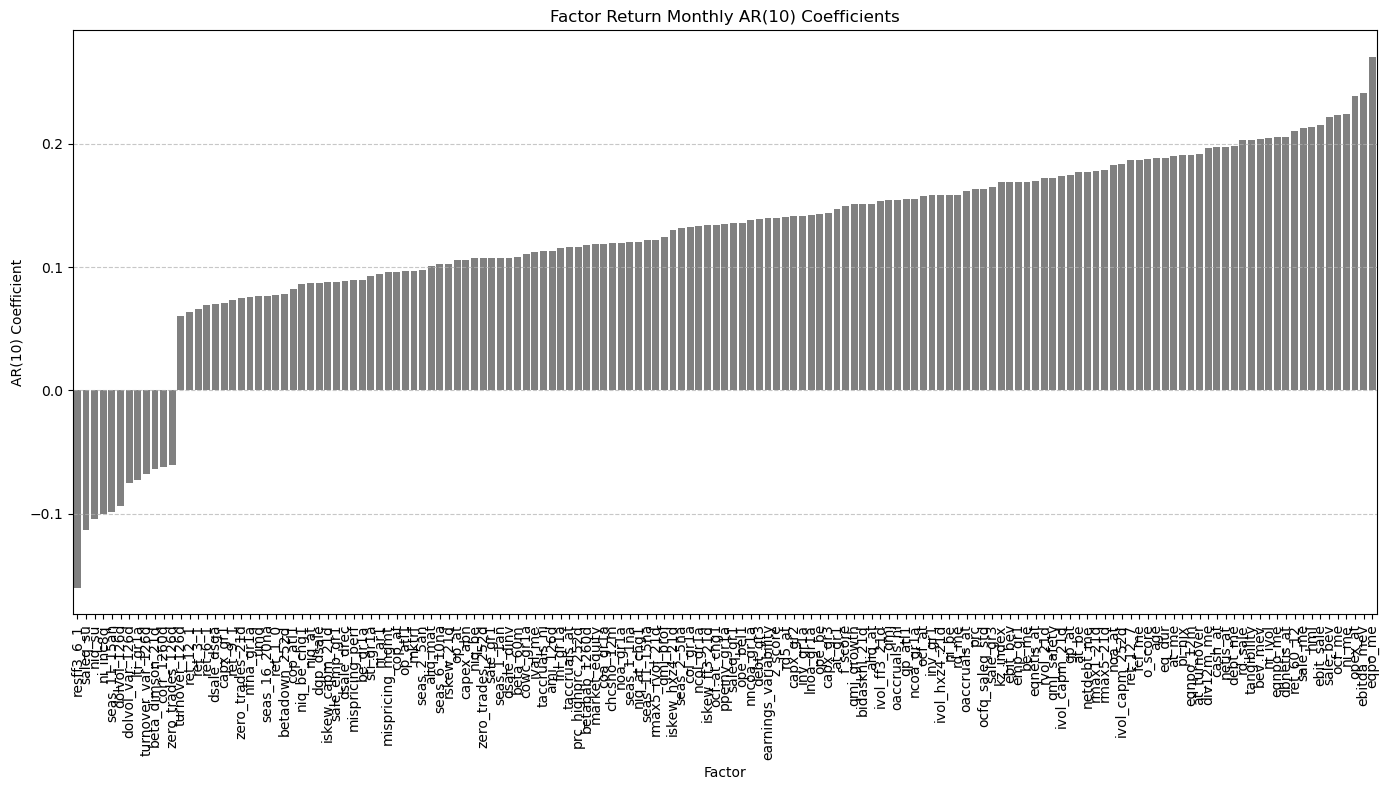

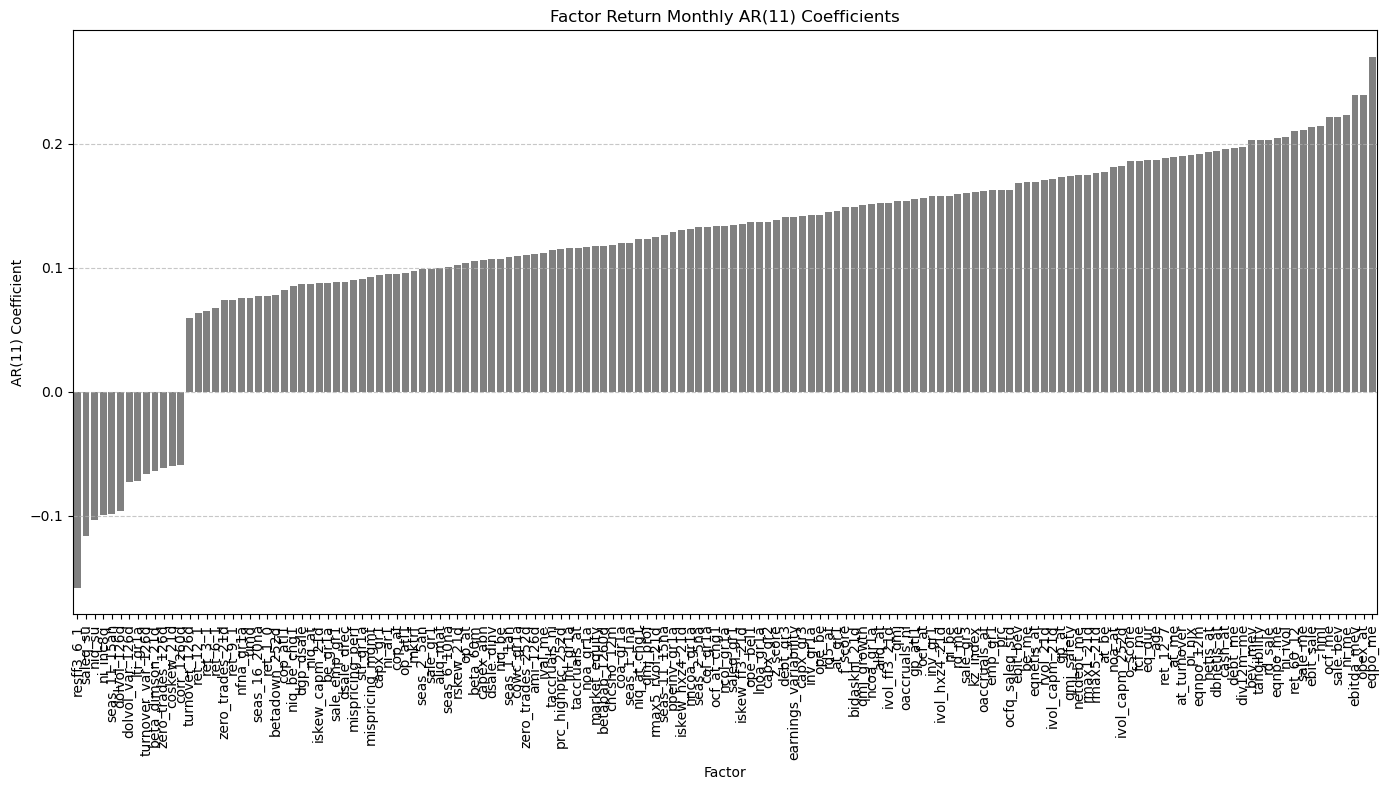

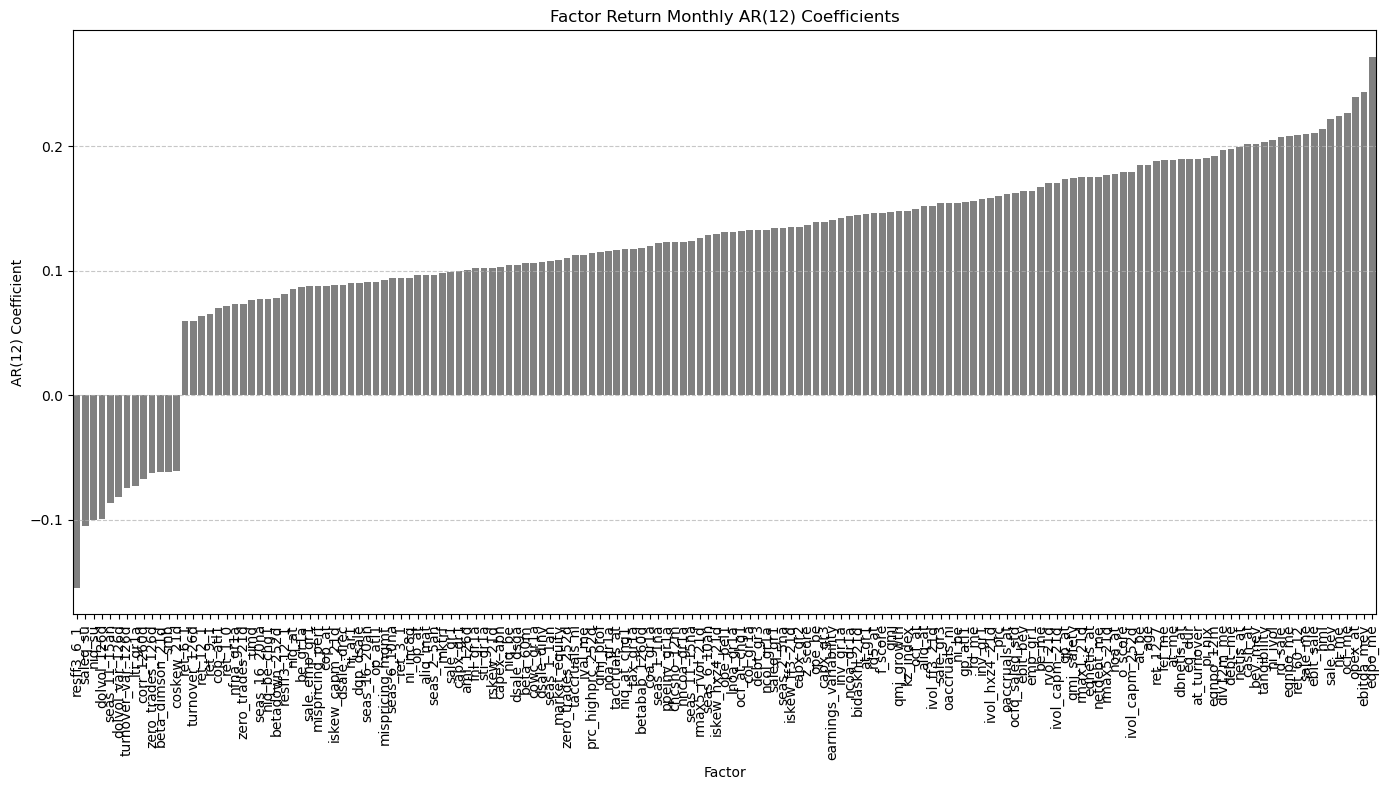

In [79]:
plot_significant_factors_across_ar_models(s_factor_1_12, 12, img_show=True)

In [80]:
def analyze_persistence_of_factors(significant_factors_across_models, max_n):
    persistence_counts = {factor: [0] * max_n for factor in significant_factors_across_models[1].keys()}
    
    for n in range(1, max_n + 1):
        significant_factors = significant_factors_across_models.get(n, {})
        
        for factor in persistence_counts.keys():
            if factor in significant_factors:
                persistence_counts[factor][n-1] = 1
    
    persistence_summary = {factor: sum(counts) for factor, counts in persistence_counts.items()}
    
    return persistence_summary, persistence_counts

In [81]:
def plot_persistence_summary(persistence_summary):
    sorted_summary = sorted(persistence_summary.items(), key=lambda x: x[1], reverse=True)
    factors = [item[0] for item in sorted_summary]
    persistence_counts = [item[1] for item in sorted_summary]
    
    plt.figure(figsize=(14, 8))
    sns.barplot(x=factors, y=persistence_counts, color='gray')
    
    plt.xticks(rotation=90)
    plt.xlabel('Factor')
    plt.ylabel('Persistence Count')
    plt.title('Factor Persistence Across AR Models')
    plt.grid(True, axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

In [82]:
persistence_summary, persistence_counts = analyze_persistence_of_factors(s_factor_1_12, 12)

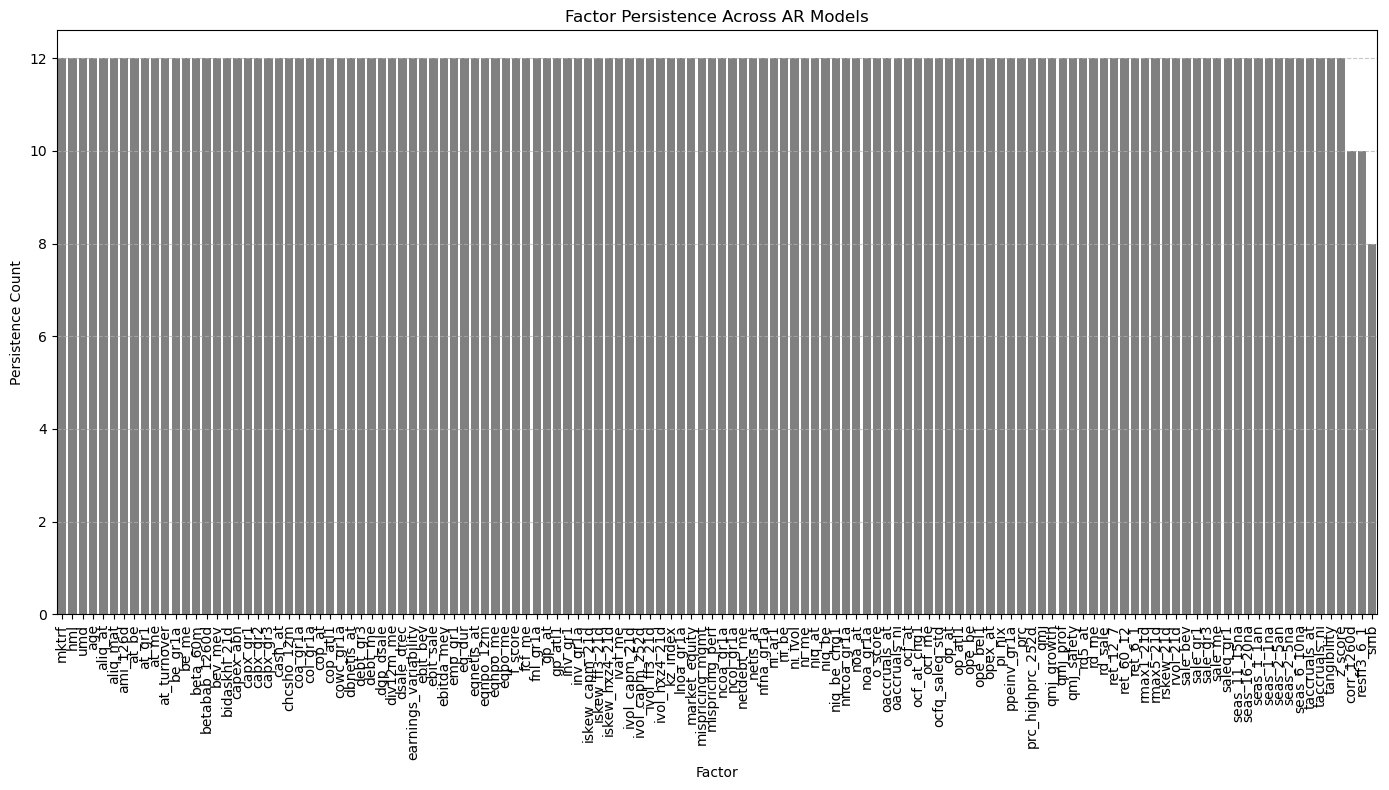

In [83]:
plot_persistence_summary(persistence_summary)

In [87]:
persistence_summary.keys()

dict_keys(['mktrf', 'smb', 'hml', 'umd', 'age', 'aliq_at', 'aliq_mat', 'ami_126d', 'at_be', 'at_gr1', 'at_me', 'at_turnover', 'be_gr1a', 'be_me', 'beta_60m', 'betabab_1260d', 'bev_mev', 'bidaskhl_21d', 'capex_abn', 'capx_gr1', 'capx_gr2', 'capx_gr3', 'cash_at', 'chcsho_12m', 'coa_gr1a', 'col_gr1a', 'cop_at', 'cop_atl1', 'corr_1260d', 'cowc_gr1a', 'dbnetis_at', 'debt_gr3', 'debt_me', 'dgp_dsale', 'div12m_me', 'dsale_drec', 'earnings_variability', 'ebit_bev', 'ebit_sale', 'ebitda_mev', 'emp_gr1', 'eq_dur', 'eqnetis_at', 'eqnpo_12m', 'eqnpo_me', 'eqpo_me', 'f_score', 'fcf_me', 'fnl_gr1a', 'gp_at', 'gp_atl1', 'inv_gr1', 'inv_gr1a', 'iskew_capm_21d', 'iskew_ff3_21d', 'iskew_hxz4_21d', 'ival_me', 'ivol_capm_21d', 'ivol_capm_252d', 'ivol_ff3_21d', 'ivol_hxz4_21d', 'kz_index', 'lnoa_gr1a', 'market_equity', 'mispricing_mgmt', 'mispricing_perf', 'ncoa_gr1a', 'ncol_gr1a', 'netdebt_me', 'netis_at', 'nfna_gr1a', 'ni_ar1', 'ni_be', 'ni_ivol', 'ni_me', 'niq_at', 'niq_be', 'niq_be_chg1', 'nncoa_gr1a',

# Trading by long-short signal

In [140]:
def calculate_long_short_signals(data, start, end):
    signals = pd.DataFrame(index=data.index, columns=data.columns)
    
    for i in range(end, len(data)):
        if start == 1 and end == 1:
            # Use the previous period's returns for signals
            period_returns = data.iloc[i-1]
            long_signals = (period_returns > 0).astype(int)
            short_signals = (period_returns < 0).astype(int) * -1
        else:
            # Calculate the sum of returns for the given period
            period_returns = data.iloc[i-end:i]
            sum_returns = period_returns.sum()

            # Generate long-short signals based on the sum of returns
            long_signals = (sum_returns > 0).astype(int)
            short_signals = (sum_returns < 0).astype(int) * -1

        signals.iloc[i] = long_signals + short_signals

    return signals

In [141]:
signal_1m = calculate_long_short_signals(usa_fac_ewm, 1, 1)

In [142]:
signal_12m = calculate_long_short_signals(usa_fac_ewm, 1, 12)

In [146]:
def apply_long_short_strategy(returns, signals):
    # Initialize a DataFrame to store the strategy returns
    strategy_returns = pd.DataFrame(index=returns.index, columns=['Long_Short_Return'])

    for i in range(len(returns)):
        signal = signals.iloc[i]
        period_returns = returns.iloc[i]

        # Calculate the long and short returns based on the signals
        long_return = (signal == 1) * period_returns
        short_return = (signal == -1) * period_returns

        # Calculate the strategy return as the average of long and short returns
        strategy_return = long_return.mean() - short_return.mean()
        
        # Store the strategy return in the DataFrame
        strategy_returns.iloc[i] = strategy_return

    return strategy_returns

In [149]:
ls_1m = apply_long_short_strategy(usa_fac_ewm, signal_1m)

In [150]:
ls_12m = apply_long_short_strategy(usa_fac_ewm, signal_12m)

In [156]:
def plot_strategy_performance(strategy_returns):
    # Convert index to datetime if it is not already
    if isinstance(strategy_returns.index, pd.PeriodIndex):
        strategy_returns.index = strategy_returns.index.to_timestamp()

    # Calculate cumulative returns
    cumulative_returns = (1 + strategy_returns).cumprod() - 1

    # Plot cumulative returns
    plt.figure(figsize=(14, 8))
    plt.plot(cumulative_returns, label='Long-Short Strategy Returns')
    plt.xlabel('Date')
    plt.ylabel('Cumulative Returns')
    plt.title('Long-Short Strategy Performance')
    plt.legend()
    plt.grid(True)
    plt.show()

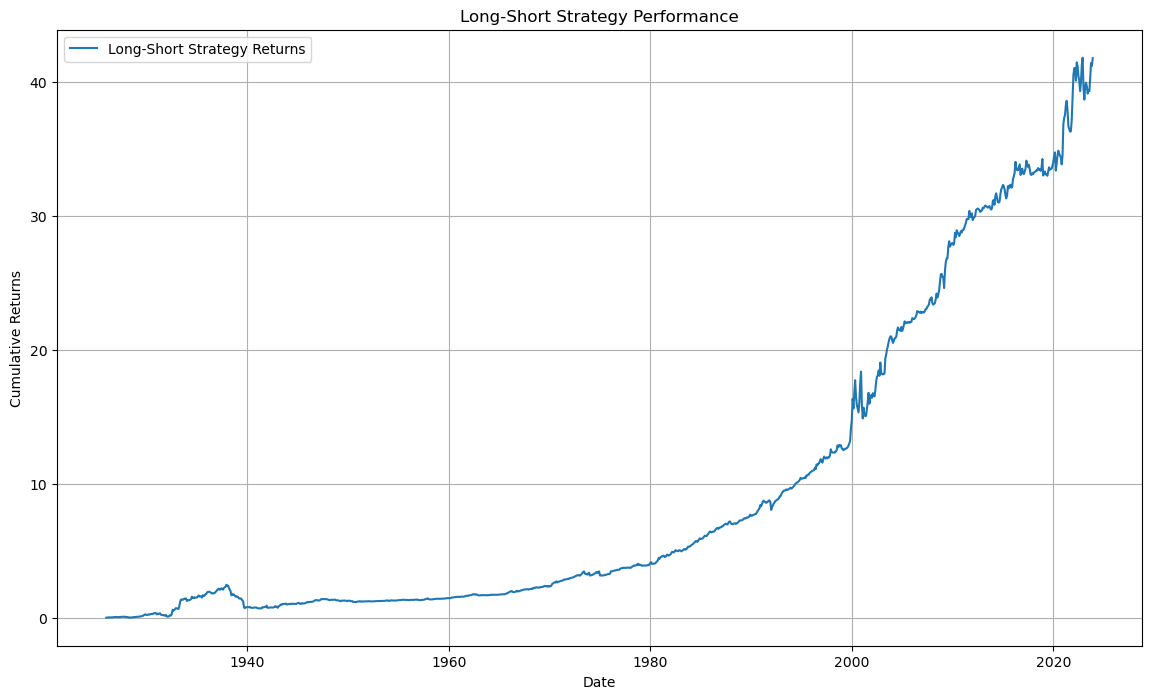

In [157]:
plot_strategy_performance(ls_1m)

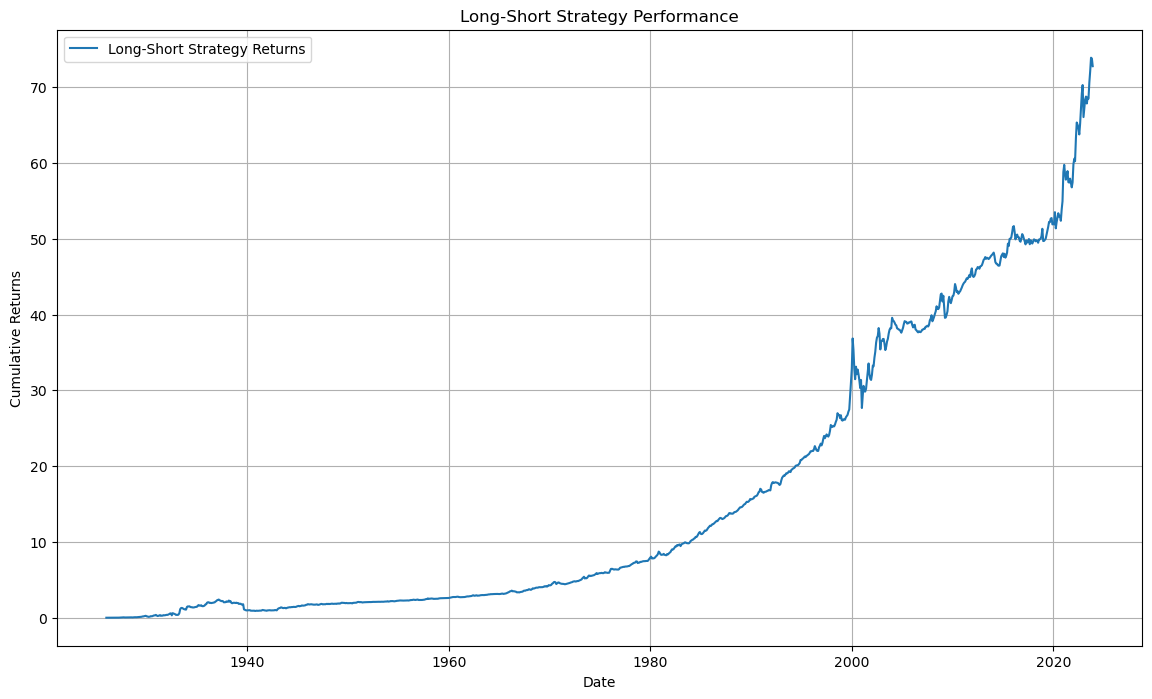

In [158]:
plot_strategy_performance(ls_12m)

In [172]:
states = classify_states(usa_fac_ewm, (1,1), (1,12))

In [173]:
for i,j,k in zip(states['mktrf'], signal_1m['mktrf'], signal_12m['mktrf']):
    print(i,j,k)

nan nan nan
nan 0 nan
nan 0 nan
nan 0 nan
nan 0 nan
nan 0 nan
nan 0 nan
nan 1 nan
nan 1 nan
nan 1 nan
nan -1 nan
nan 1 nan
nan 1 1
nan -1 1
nan 1 1
nan 1 1
nan 1 1
nan 1 1
Correction -1 1
Bull 1 1
Bull 1 1
Bull 1 1
Correction -1 1
Bull 1 1
Bull 1 1
Correction -1 1
Correction -1 1
Bull 1 1
Bull 1 1
Bull 1 1
Correction -1 1
Bull 1 1
Bull 1 1
Bull 1 1
Bull 1 1
Bull 1 1
Bull 1 1
Bull 1 1
Correction -1 1
Correction -1 1
Bull 1 1
Correction -1 1
Bull 1 1
Bull 1 1
Bull 1 1
Correction -1 1
Correction -1 1
Bear -1 -1
Rebound 1 -1
Rebound 1 -1
Rebound 1 -1
Rebound 1 -1
Bear -1 -1
Bear -1 -1
Bear -1 -1
Rebound 1 -1
Rebound 1 -1
Bear -1 -1
Bear -1 -1
Bear -1 -1
Bear -1 -1
Rebound 1 -1
Rebound 1 -1
Bear -1 -1
Bear -1 -1
Bear -1 -1
Rebound 1 -1
Bear -1 -1
Rebound 1 -1
Bear -1 -1
Rebound 1 -1
Bear -1 -1
Bear -1 -1
Bear -1 -1
Rebound 1 -1
Bear -1 -1
Bear -1 -1
Bear -1 -1
Bear -1 -1
Rebound 1 -1
Rebound 1 -1
Correction -1 1
Bear -1 -1
Bear -1 -1
Bull 1 1
Bull 1 1
Bear -1 -1
Bull 1 1
Bull 1 1
Bull 1 1
B

In [169]:
states['mktrf']

1926-01                  NaN
1926-02                  NaN
1926-03                  NaN
1926-04                  NaN
1926-05                  NaN
                 ...        
2023-08    positive_positive
2023-09    negative_positive
2023-10    negative_positive
2023-11    negative_positive
2023-12    positive_positive
Freq: M, Length: 1176, dtype: object

In [168]:
signal_1m['mktrf']

1926-01    NaN
1926-02      0
1926-03      0
1926-04      0
1926-05      0
          ... 
2023-08      1
2023-09     -1
2023-10     -1
2023-11     -1
2023-12      1
Freq: M, Name: mktrf, Length: 1176, dtype: object

# Split by factor theme

In [176]:
usa_th_ew

,location,name,freq,weighting,n_factors,date,ret
0,usa,accruals,monthly,ew,1,1946-01-31,0.035107
1,usa,accruals,monthly,ew,1,1946-02-28,0.000442
2,usa,accruals,monthly,ew,1,1946-03-31,0.029271
3,usa,accruals,monthly,ew,1,1946-04-30,0.030456
4,usa,accruals,monthly,ew,1,1946-05-31,0.006532
...,...,...,...,...,...,...,...
14628,usa,value,monthly,ew,18,2023-08-31,0.036700
14629,usa,value,monthly,ew,18,2023-09-30,0.035441
14630,usa,value,monthly,ew,18,2023-10-31,0.040647
14631,usa,value,monthly,ew,18,2023-11-30,-0.001742


In [177]:
usa_th_ew.drop(columns = ['freq', 'weighting', 'location','n_factors'], inplace = True)
usa_th_ew = usa_th_ew.pivot_table(index='date', columns='name', values='ret')

In [181]:
usa_th_ew.index = pd.to_datetime(usa_th_ew.index)
usa_th_ew.index = usa_th_ew.index.to_period('M')

In [182]:
usa_th_ewm = pd.merge(ff_data[['mktrf']], usa_th_ew, left_index=True, right_index=True)

In [187]:
usa_th_ewm.columns

Index(['mktrf', 'accruals', 'debt_issuance', 'investment', 'low_leverage',
       'low_risk', 'momentum', 'profit_growth', 'profitability', 'quality',
       'seasonality', 'short_term_reversal', 'size', 'value'],
      dtype='object')

In [193]:
pd.DataFrame(usa_th_ewm['accruals'])

,accruals
1926-07,NaN
1926-08,NaN
1926-09,NaN
1926-10,NaN
1926-11,NaN
...,...
2023-08,-0.011499
2023-09,-0.015789
2023-10,-0.004134
2023-11,0.019044


In [194]:
signal_acc_1m = calculate_long_short_signals(pd.DataFrame(usa_th_ewm['accruals']), 1, 1)
signal_dbt_1m = calculate_long_short_signals(pd.DataFrame(usa_th_ewm['debt_issuance']), 1, 1)
signal_inv_1m = calculate_long_short_signals(pd.DataFrame(usa_th_ewm['investment']), 1, 1)
signal_lev_1m = calculate_long_short_signals(pd.DataFrame(usa_th_ewm['low_leverage']), 1, 1)
signal_rsk_1m = calculate_long_short_signals(pd.DataFrame(usa_th_ewm['low_risk']), 1, 1)
signal_mmt_1m = calculate_long_short_signals(pd.DataFrame(usa_th_ewm['momentum']), 1, 1)
signal_pgr_1m = calculate_long_short_signals(pd.DataFrame(usa_th_ewm['profit_growth']), 1, 1)
signal_prf_1m = calculate_long_short_signals(pd.DataFrame(usa_th_ewm['profitability']), 1, 1)
signal_qlt_1m = calculate_long_short_signals(pd.DataFrame(usa_th_ewm['quality']), 1, 1)
signal_sea_1m = calculate_long_short_signals(pd.DataFrame(usa_th_ewm['seasonality']), 1, 1)
signal_str_1m = calculate_long_short_signals(pd.DataFrame(usa_th_ewm['short_term_reversal']), 1, 1)
signal_siz_1m = calculate_long_short_signals(pd.DataFrame(usa_th_ewm['size']), 1, 1)
signal_val_1m = calculate_long_short_signals(pd.DataFrame(usa_th_ewm['value']), 1, 1)

In [195]:
signal_acc_12m = calculate_long_short_signals(pd.DataFrame(usa_th_ewm['accruals']), 1, 12)
signal_dbt_12m = calculate_long_short_signals(pd.DataFrame(usa_th_ewm['debt_issuance']), 1, 12)
signal_inv_12m = calculate_long_short_signals(pd.DataFrame(usa_th_ewm['investment']), 1, 12)
signal_lev_12m = calculate_long_short_signals(pd.DataFrame(usa_th_ewm['low_leverage']), 1, 12)
signal_rsk_12m = calculate_long_short_signals(pd.DataFrame(usa_th_ewm['low_risk']), 1, 12)
signal_mmt_12m = calculate_long_short_signals(pd.DataFrame(usa_th_ewm['momentum']), 1, 12)
signal_pgr_12m = calculate_long_short_signals(pd.DataFrame(usa_th_ewm['profit_growth']), 1, 12)
signal_prf_12m = calculate_long_short_signals(pd.DataFrame(usa_th_ewm['profitability']), 1, 12)
signal_qlt_12m = calculate_long_short_signals(pd.DataFrame(usa_th_ewm['quality']), 1, 12)
signal_sea_12m = calculate_long_short_signals(pd.DataFrame(usa_th_ewm['seasonality']), 1, 12)
signal_str_12m = calculate_long_short_signals(pd.DataFrame(usa_th_ewm['short_term_reversal']), 1, 12)
signal_siz_12m = calculate_long_short_signals(pd.DataFrame(usa_th_ewm['size']), 1, 12)
signal_val_12m = calculate_long_short_signals(pd.DataFrame(usa_th_ewm['value']), 1, 12)

In [198]:
ls_acc_1m = apply_long_short_strategy(usa_th_ewm, signal_acc_1m)
ls_dbt_1m = apply_long_short_strategy(usa_th_ewm, signal_dbt_1m)
ls_inv_1m = apply_long_short_strategy(usa_th_ewm, signal_inv_1m)
ls_lev_1m = apply_long_short_strategy(usa_th_ewm, signal_lev_1m)
ls_rsk_1m = apply_long_short_strategy(usa_th_ewm, signal_rsk_1m)
ls_mmt_1m = apply_long_short_strategy(usa_th_ewm, signal_mmt_1m)
ls_pgr_1m = apply_long_short_strategy(usa_th_ewm, signal_pgr_1m)
ls_prf_1m = apply_long_short_strategy(usa_th_ewm, signal_prf_1m)
ls_qlt_1m = apply_long_short_strategy(usa_th_ewm, signal_qlt_1m)
ls_sea_1m = apply_long_short_strategy(usa_th_ewm, signal_sea_1m)
ls_str_1m = apply_long_short_strategy(usa_th_ewm, signal_str_1m)
ls_siz_1m = apply_long_short_strategy(usa_th_ewm, signal_siz_1m)
ls_val_1m = apply_long_short_strategy(usa_th_ewm, signal_val_1m)

In [199]:
ls_acc_12m = apply_long_short_strategy(usa_th_ewm, signal_acc_12m)
ls_dbt_12m = apply_long_short_strategy(usa_th_ewm, signal_dbt_12m)
ls_inv_12m = apply_long_short_strategy(usa_th_ewm, signal_inv_12m)
ls_lev_12m = apply_long_short_strategy(usa_th_ewm, signal_lev_12m)
ls_rsk_12m = apply_long_short_strategy(usa_th_ewm, signal_rsk_12m)
ls_mmt_12m = apply_long_short_strategy(usa_th_ewm, signal_mmt_12m)
ls_pgr_12m = apply_long_short_strategy(usa_th_ewm, signal_pgr_12m)
ls_prf_12m = apply_long_short_strategy(usa_th_ewm, signal_prf_12m)
ls_qlt_12m = apply_long_short_strategy(usa_th_ewm, signal_qlt_12m)
ls_sea_12m = apply_long_short_strategy(usa_th_ewm, signal_sea_12m)
ls_str_12m = apply_long_short_strategy(usa_th_ewm, signal_str_12m)
ls_siz_12m = apply_long_short_strategy(usa_th_ewm, signal_siz_12m)
ls_val_12m = apply_long_short_strategy(usa_th_ewm, signal_val_12m)

In [ ]:
plot_strategy_performance(ls_acc_1m)
plot_strategy_performance(ls_dbt_1m)
plot_strategy_performance(ls_inv_1m)
plot_strategy_performance(ls_lev_1m)
plot_strategy_performance(ls_rsk_1m)
plot_strategy_performance(ls_mmt_1m)
plot_strategy_performance(ls_pgr_1m)
plot_strategy_performance(ls_prf_1m)
plot_strategy_performance(ls_qlt_1m)
plot_strategy_performance(ls_sea_1m)
plot_strategy_performance(ls_str_1m)
plot_strategy_performance(ls_siz_1m)
plot_strategy_performance(ls_val_1m)

In [ ]:
plot_strategy_performance(ls_acc_12m)
plot_strategy_performance(ls_dbt_12m)
plot_strategy_performance(ls_inv_12m)
plot_strategy_performance(ls_lev_12m)
plot_strategy_performance(ls_rsk_12m)
plot_strategy_performance(ls_mmt_12m)
plot_strategy_performance(ls_pgr_12m)
plot_strategy_performance(ls_prf_12m)
plot_strategy_performance(ls_qlt_12m)
plot_strategy_performance(ls_sea_12m)
plot_strategy_performance(ls_str_12m)
plot_strategy_performance(ls_siz_12m)
plot_strategy_performance(ls_val_12m)